### Setup Zelle

In [ ]:
# === Setup / Gemeinsame Funktionen für alle Zellen ===
import os, time, warnings
import numpy as np
import pandas as pd

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial.distance import cdist, pdist, squareform

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


# ---------------------------
# Helpers
# ---------------------------
def _bh_fdr(pvals: np.ndarray):
    """Benjamini–Hochberg FDR-Korrektur. Rückgabe: q-Values (gleiche Reihenfolge)."""
    p = np.asarray(pvals, dtype=float)
    n = p.size
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(1, n + 1))
    # ensure monotonicity
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = q
    return np.minimum(out, 1.0)


def _psi(x_base: np.ndarray, x_new: np.ndarray, n_bins: int = 10, eps: float = 1e-6):
    """
    Population Stability Index (PSI), Bins nach Baseline-Quantilen.
    """
    x_base = np.asarray(x_base, dtype=float)
    x_new = np.asarray(x_new, dtype=float)
    x_base = x_base[~np.isnan(x_base)]
    x_new = x_new[~np.isnan(x_new)]
    if x_base.size < 5 or x_new.size < 5:
        return np.nan
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(x_base, qs))
    if edges.size < 3:
        return np.nan
    base_hist, _ = np.histogram(x_base, bins=edges)
    new_hist, _ = np.histogram(x_new, bins=edges)
    base_prop = base_hist / max(base_hist.sum(), 1)
    new_prop  = new_hist  / max(new_hist.sum(), 1)
    base_prop = np.clip(base_prop, eps, None)
    new_prop  = np.clip(new_prop,  eps, None)
    return float(np.sum((new_prop - base_prop) * np.log(new_prop / base_prop)))


def _wasserstein_over_iqr(x_base: np.ndarray, x_new: np.ndarray):
    w = stats.wasserstein_distance(x_base[~np.isnan(x_base)], x_new[~np.isnan(x_new)])
    iqr = np.subtract(*np.nanpercentile(x_base, [75, 25]))
    scale = iqr if iqr > 0 else np.nanstd(x_base)
    return np.nan if (scale is None or scale == 0) else float(w / scale)


def _safe_numeric(df: pd.DataFrame, exclude=()):
    num = df.select_dtypes(include=[np.number]).copy()
    for col in exclude:
        if col in num.columns:
            num.drop(columns=[col], inplace=True)
    return num


# ---------------------------
# 1) Univariate: Kennzahlen + KS + FDR
# ---------------------------
def univariate_drift_metrics(X_real: pd.DataFrame,
                             X_synth: pd.DataFrame,
                             exclude=("Verletzungsstatus",),
                             n_bins_psi: int = 10) -> pd.DataFrame:
    """
    Liefert pro Feature: KS, q (FDR), SMD, Var-Ratio, PSI, Wasserstein/IQR, ΔMedian.
    """
    A = _safe_numeric(X_real, exclude)
    B = _safe_numeric(X_synth, exclude)
    common = [c for c in A.columns if c in B.columns]
    rows = []
    pvals = []
    for col in common:
        a = A[col].to_numpy(dtype=float)
        b = B[col].to_numpy(dtype=float)
        a = a[~np.isnan(a)]
        b = b[~np.isnan(b)]
        if a.size < 5 or b.size < 5:
            rows.append(dict(feature=col, ks=np.nan, p=np.nan, smd=np.nan,
                             var_ratio=np.nan, psi=np.nan, w_over_iqr=np.nan,
                             d_median=np.nan))
            pvals.append(np.nan)
            continue
        ks_stat, p = stats.ks_2samp(a, b, alternative="two-sided", mode="auto")
        smd = (np.nanmean(b) - np.nanmean(a)) / (np.nanstd(a, ddof=1) + 1e-12)
        var_ratio = (np.nanvar(b, ddof=1) + 1e-12) / (np.nanvar(a, ddof=1) + 1e-12)
        psi = _psi(a, b, n_bins=n_bins_psi)
        w_iqr = _wasserstein_over_iqr(a, b)
        d_med = float(np.nanmedian(b) - np.nanmedian(a))
        rows.append(dict(feature=col, ks=ks_stat, p=p, smd=smd,
                         var_ratio=var_ratio, psi=psi, w_over_iqr=w_iqr,
                         d_median=d_med))
        pvals.append(p)
    df = pd.DataFrame(rows)
    if len(df) and np.isfinite(df["p"]).any():
        df["q_fdr"] = _bh_fdr(df["p"].fillna(1.0).to_numpy())
    else:
        df["q_fdr"] = np.nan
    return df.sort_values(["q_fdr", "ks"], ascending=[True, False])


# ---------------------------
# 2) Verteilungsplots (Overlay)
# ---------------------------

def plot_feature_overlay(X_real: pd.DataFrame,
                         X_synth: pd.DataFrame,
                         feature: str,
                         bins: int = 40):
    """
    Overlay: Histogramm + einfache KDE (Real vs. Synth).
    - Dichtevergleich (density=True), aber Labels zeigen n (Stichprobengröße).
    - Speichert nichts, zeigt direkt und schließt danach die Figure (Ausgabe bleibt sichtbar).
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy import stats

    if feature not in X_real.columns or feature not in X_synth.columns:
        print(f"[plot] {feature} nicht in beiden DataFrames.")
        return

    a = X_real[feature].dropna().to_numpy(dtype=float)
    b = X_synth[feature].dropna().to_numpy(dtype=float)
    if a.size < 5 or b.size < 5:
        print(f"[plot] zu wenig Daten in {feature}")
        return

    data_min = np.nanmin(np.concatenate([a, b]))
    data_max = np.nanmax(np.concatenate([a, b]))

    fig, ax = plt.subplots(figsize=(7, 4.2))
    # Variante C: density=True + n im Label
    ax.hist(a, bins=bins, alpha=0.45, density=True, label=f"Real (n={len(a)})",  edgecolor="none")
    ax.hist(b, bins=bins, alpha=0.45, density=True, label=f"Synth (n={len(b)})", edgecolor="none")

    # einfache KDE (ebenfalls Dichte)
    try:
        kde_a = stats.gaussian_kde(a)
        kde_b = stats.gaussian_kde(b)
        xs = np.linspace(data_min, data_max, 300)
        ax.plot(xs, kde_a(xs), lw=1.4, label="Real KDE")
        ax.plot(xs, kde_b(xs), lw=1.4, label="Synth KDE")
    except Exception:
        pass

    ax.set_title(f"Distribution Overlay – {feature}")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()

    plt.show()
    plt.close(fig)  # Figure schließen (Ausgabe bleibt im Notebook sichtbar)


# ---------------------------
# 3) Multivariat – kompakt (ein Zahlenfaktor + Korrelation)
# ---------------------------
def energy_distance_multivariate(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",)):
    """
    Energy Distance zwischen zwei multivariaten Samples (kleiner ist ähnlicher).
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    if len(A) < 3 or len(B) < 3:
        return np.nan
    # E = 2 E||X-Y|| - E||X-X'|| - E||Y-Y'||
    d_xy = cdist(A, B, metric="euclidean")
    d_xx = pdist(A, metric="euclidean")
    d_yy = pdist(B, metric="euclidean")
    return float(2 * d_xy.mean() - d_xx.mean() - d_yy.mean())


def mmd_rbf(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",), gamma="median"):
    """
    Maximum Mean Discrepancy (RBF). Größer = stärkerer Drift.
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    if len(A) < 3 or len(B) < 3:
        return np.nan
    Z = np.vstack([A, B])
    if gamma == "median":
        d2 = squareform(pdist(Z, metric="sqeuclidean"))
        med = np.median(d2[d2 > 0])
        gam = 1.0 / (med + 1e-12)
    else:
        gam = float(gamma)
    def _k(X, Y):  # RBF kernel
        return np.exp(-gam * cdist(X, Y, metric="sqeuclidean"))
    Kxx = _k(A, A); Kyy = _k(B, B); Kxy = _k(A, B)
    n = A.shape[0]; m = B.shape[0]
    # Unbiased estimator
    term_x = (np.sum(Kxx) - np.trace(Kxx)) / (n*(n-1))
    term_y = (np.sum(Kyy) - np.trace(Kyy)) / (m*(m-1))
    term_xy = (2 * np.sum(Kxy)) / (n*m)
    return float(term_x + term_y - term_xy)


def correlation_drift(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",)):
    """
    Liefert: Frobenius-Norm der ΔKorrelation (skaliert), #Sign-Flips, Top-Δr-Paare.
    """
    A = _safe_numeric(X_real, exclude)
    B = _safe_numeric(X_synth, exclude)
    common = [c for c in A.columns if c in B.columns]
    A = A[common]; B = B[common]
    if A.shape[0] < 5 or B.shape[0] < 5:
        return dict(fro_norm=np.nan, sign_flips=np.nan, top_pairs=[])
    R1 = A.corr().fillna(0.0).to_numpy()
    R2 = B.corr().fillna(0.0).to_numpy()
    D = R2 - R1
    p = R1.shape[0]
    fro = np.linalg.norm(D, ord="fro") / np.sqrt(p*p)  # skaliert [0..]
    # Sign-Flips nur oberes Dreieck (ohne Diagonale)
    mask = np.triu(np.ones_like(R1, dtype=bool), 1)
    flips = np.sum((np.sign(R1[mask]) * np.sign(R2[mask])) == -1)
    # Top-Paare
    idxs = np.argpartition(np.abs(D[mask]), -10)[-10:]
    absD = np.abs(D[mask]).flatten()
    order = idxs[np.argsort(-absD[idxs])]
    top_pairs = []
    # rekonstruiere Paare:
    ii, jj = np.where(mask)
    for k in order:
        i, j = ii[k], jj[k]
        top_pairs.append((common[i], common[j], float(D[i, j])))
    return dict(fro_norm=float(fro), sign_flips=int(flips), top_pairs=top_pairs)


# ---------------------------
# 4) Downstream – ein Faktor (AUC eines Origin-Detektors)
# ---------------------------
def origin_discriminability_auc(X_real: pd.DataFrame, X_synth: pd.DataFrame, exclude=("Verletzungsstatus",), cv=5, random_state=42):
    """
    Trainiert LR, die 'Origin' (real=0, synth=1) unterscheiden soll. AUC nahe 0.5 = gut.
    """
    A = _safe_numeric(X_real, exclude).to_numpy(dtype=float)
    B = _safe_numeric(X_synth, exclude).to_numpy(dtype=float)
    A = A[~np.any(np.isnan(A), axis=1)]
    B = B[~np.any(np.isnan(B), axis=1)]
    n = min(len(A), len(B))
    if n < 20:
        return np.nan
    # balancieren
    rng = np.random.default_rng(random_state)
    A = A[rng.choice(len(A), n, replace=False)]
    B = B[rng.choice(len(B), n, replace=False)]
    X = np.vstack([A, B])
    y = np.array([0]*n + [1]*n)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    aucs = []
    for tr, te in skf.split(X, y):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr]); Xte = scaler.transform(X[te])
        clf = LogisticRegression(max_iter=500, n_jobs=None)
        clf.fit(Xtr, y[tr])
        p = clf.predict_proba(Xte)[:, 1]
        aucs.append(roc_auc_score(y[te], p))
    return float(np.mean(aucs))


# ---------------------------
# 5) Plausibilitäts-Checks (einfach & konfigurierbar)
# ---------------------------
def plausibility_report(df: pd.DataFrame,
                        bounds: dict = None,
                        nonneg_patterns=("force", "moment", "impulse", "time", "rsi", "stiff", "rate"),
                        angle_patterns=("angle",),
                        angle_bounds=(-180, 180)):
    """
    bounds: dict {'FeatureName': (min,max)} – harte Grenzen.
    *_patterns: lower-case Substrings für Heuristiken.
    Rückgabe: dict mit Counts & Liste verletzter Felder.
    """
    bad_cells = []
    n = len(df)
    cols = df.select_dtypes(include=[np.number]).columns
    # harte Grenzen
    if bounds:
        for col, (mn, mx) in bounds.items():
            if col in df.columns:
                v = df[col].to_numpy(dtype=float)
                mask = (~np.isnan(v)) & ((v < mn) | (v > mx))
                bad = int(mask.sum())
                if bad:
                    bad_cells.append((col, f"bounds[{mn},{mx}]", bad))
    # nonnegativ
    for col in cols:
        name = col.lower()
        if any(k in name for k in nonneg_patterns):
            v = df[col].to_numpy(dtype=float)
            bad = int(np.sum(v[~np.isnan(v)] < 0))
            if bad:
                bad_cells.append((col, "nonneg", bad))
    # Winkel
    if angle_bounds is not None:
        mn, mx = angle_bounds
        for col in cols:
            name = col.lower()
            if any(k in name for k in angle_patterns):
                v = df[col].to_numpy(dtype=float)
                mask = (~np.isnan(v)) & ((v < mn) | (v > mx))
                bad = int(mask.sum())
                if bad:
                    bad_cells.append((col, f"angle[{mn},{mx}]", bad))
    total_bad = sum(b for _, _, b in bad_cells) if bad_cells else 0
    return dict(total_rows=n, total_violations=total_bad, details=bad_cells)


# ---------------------------
# Augmentierung (nur Gruppierung nach 'Verletzungsstatus')
# ---------------------------
def perform_clustering(X_sub, max_clusters=4):
    cols = [c for c in X_sub.columns if c != "Verletzungsstatus"]
    X_num = X_sub[cols]
    corr = X_num.corr().abs().fillna(0)
    corr = (corr + corr.T) / 2
    dist = np.clip(1 - corr, a_min=0, a_max=None)
    dists = squareform(dist.values)
    Z = linkage(dists, method='ward')
    cluster_labels = fcluster(Z, max_clusters, criterion='maxclust')
    clusters = {}
    for col, label in zip(cols, cluster_labels):
        clusters.setdefault(label, []).append(col)
    return clusters

def augment_subgroup(X_sub, clusters, p_augment=0.7, cov_jitter=1e-6):
    augmented_rows = []
    cluster_params = {}
    for cl_id, cols in clusters.items():
        cluster_data = X_sub[cols]
        mu = cluster_data.mean().values
        if len(cols) == 1:
            cov = np.atleast_2d(np.var(cluster_data.values.flatten(), ddof=0))
        else:
            cov = np.cov(cluster_data.values, rowvar=False)
        cov = np.asarray(cov, dtype=float)
        cov += np.eye(cov.shape[0]) * (cov_jitter * (np.trace(cov) / max(cov.shape[0], 1) + 1e-12))
        cluster_params[cl_id] = (mu, cov, cols)

    for _, row in X_sub.iterrows():
        new_row = row.copy()
        for _, (mu, cov, cols) in cluster_params.items():
            if np.random.rand() < p_augment:
                new_values = np.random.multivariate_normal(mu, cov)
                for col, val in zip(cols, new_values):
                    new_row[col] = val
        augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    if "Verletzungsstatus" in augmented_df.columns:
        augmented_df["Verletzungsstatus"] = augmented_df["Verletzungsstatus"].astype(int)
    return augmented_df

def process_group_cluster(group_df, num_new_samples, max_clusters, p_augment):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    return pd.concat(aug_list, axis=0)

def augment_training_data_cluster(X_train, y_train, num_new_samples=1, max_clusters=4, p_augment=0.7, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [g for _, g in df_train.groupby(["Verletzungsstatus"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster)(group_df, num_new_samples, max_clusters, p_augment)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def add_noise_to_data(df, noise_factor=0.1):
    df_noisy = df.copy()
    numeric_cols = [c for c in df_noisy.select_dtypes(include=['float64', 'int64']).columns if c != "Verletzungsstatus"]
    for col in numeric_cols:
        std = df_noisy[col].std()
        noise = np.random.normal(0, (std if np.isfinite(std) else 0.0) * noise_factor, size=df_noisy.shape[0])
        df_noisy[col] += noise
    return df_noisy

def process_group_cluster_noise(group_df, num_new_samples, max_clusters, p_augment, noise_factor):
    group_df = group_df.reset_index(drop=True)
    clusters = perform_clustering(group_df, max_clusters=max_clusters)
    aug_list = []
    for _ in range(num_new_samples):
        aug = augment_subgroup(group_df, clusters, p_augment)
        aug_list.append(aug)
    aug_group = pd.concat(aug_list, axis=0).reset_index(drop=True)
    n = len(aug_group); half = n // 2
    global_noise = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    group_noise  = add_noise_to_data(aug_group.copy(), noise_factor=noise_factor)
    aug_noisy = pd.concat([global_noise.iloc[:half], group_noise.iloc[:half]], axis=0)
    return aug_noisy

def augment_training_data_cluster_noise(X_train, y_train, num_new_samples=1, max_clusters=4, 
                                        p_augment=0.7, noise_factor=0.1, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = [g for _, g in df_train.groupby(["Verletzungsstatus"])]
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_cluster_noise)(group_df, num_new_samples, max_clusters, p_augment, noise_factor)
        for group_df in groups
    )
    augmented_df = pd.concat(augmented_groups, axis=0).reset_index(drop=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def process_group_means(group_df, group_new_samples):
    group_df = group_df.reset_index(drop=True)
    if len(group_df) < 2: return None
    numeric_cols = [col for col in group_df.columns if col != "Verletzungsstatus"]
    pairs = np.random.choice(len(group_df), (group_new_samples, 2), replace=True)
    new_group_samples = []
    for i in range(group_new_samples):
        s1 = group_df.iloc[pairs[i, 0]]
        s2 = group_df.iloc[pairs[i, 1]]
        mean_sample = s1.copy()
        for col in numeric_cols:
            mean_sample[col] = (s1[col] + s2[col]) / 2
        mean_sample["Verletzungsstatus"] = s1["Verletzungsstatus"]
        new_group_samples.append(mean_sample)
    return pd.DataFrame(new_group_samples) if new_group_samples else None

def augment_data_by_group_means(X_train, y_train, augmentation_factor=2, n_jobs=-1):
    df_train = X_train.copy()
    df_train["Verletzungsstatus"] = y_train
    groups = df_train.groupby("Verletzungsstatus")
    total_original = len(df_train)
    total_new = int(total_original * (augmentation_factor - 1))
    group_sizes = groups.size()
    group_props = group_sizes / total_original
    tasks = []
    for injury_status, group_df in groups:
        group_new = int(total_new * group_props.loc[injury_status])
        tasks.append((group_df, group_new))
    augmented_groups = Parallel(n_jobs=n_jobs)(
        delayed(process_group_means)(group_df, group_new) for group_df, group_new in tasks
    )
    augmented_groups = [g for g in augmented_groups if g is not None]
    augmented_df = pd.concat([df_train] + augmented_groups, ignore_index=True)
    y_aug = augmented_df["Verletzungsstatus"]
    X_aug = augmented_df.drop(columns=["Verletzungsstatus"])
    return X_aug, y_aug

def augment_training_data_combined(X_train, y_train, target_size=1000, verbose=True, n_jobs=-1,
                                   max_clusters=4, noise_factor=0.1, return_synth=False):
    start_time = time.time()
    N = len(X_train)
    additional_needed = max(target_size - N, 0)
    per_method_needed = additional_needed // 3
    num_new_samples = max(per_method_needed // N, 1) if N > 0 else 0
    augmentation_factor = 1 + (per_method_needed / N) if N > 0 else 1.0

    if verbose:
        print(f"[Aug] target_size={target_size} | N={N} | per_method_needed={per_method_needed}")

    funcs_and_params = [
        (augment_training_data_cluster,       {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_training_data_cluster_noise, {"num_new_samples": num_new_samples, "n_jobs": n_jobs}),
        (augment_data_by_group_means,         {"augmentation_factor": augmentation_factor, "n_jobs": n_jobs})
    ]
    results = Parallel(n_jobs=min(3, n_jobs if n_jobs != -1 else 3))(
        delayed(lambda f, p: f(X_train, y_train, **p))(func, params) for func, params in funcs_and_params
    )
    X_aug_cluster,       y_aug_cluster       = results[0]
    X_aug_cluster_noise, y_aug_cluster_noise = results[1]
    X_aug_group_means,   y_aug_group_means   = results[2]

    def subsample(X_aug, y_aug, required):
        if required <= 0: 
            return X_aug.iloc[[]], y_aug.iloc[[]]
        if len(X_aug) > required:
            idx = np.random.choice(len(X_aug), required, replace=False)
            return X_aug.iloc[idx].reset_index(drop=True), y_aug.iloc[idx].reset_index(drop=True)
        else:
            return X_aug.reset_index(drop=True), y_aug.reset_index(drop=True)

    X_aug_cluster,       y_aug_cluster       = subsample(X_aug_cluster,       y_aug_cluster,       per_method_needed)
    X_aug_cluster_noise, y_aug_cluster_noise = subsample(X_aug_cluster_noise, y_aug_cluster_noise, per_method_needed)
    X_aug_group_means,   y_aug_group_means   = subsample(X_aug_group_means,   y_aug_group_means,   per_method_needed)

    X_synth = pd.concat([X_aug_cluster, X_aug_cluster_noise, X_aug_group_means], axis=0).reset_index(drop=True)
    y_synth = pd.concat([y_aug_cluster, y_aug_cluster_noise, y_aug_group_means], axis=0).reset_index(drop=True)

    X_total = pd.concat([X_train.reset_index(drop=True), X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train.reset_index(drop=True), y_synth], axis=0).reset_index(drop=True)

    if len(X_total) > target_size:
        idx = np.random.choice(len(X_total), target_size, replace=False)
        X_total = X_total.iloc[idx].reset_index(drop=True)
        y_total = y_total.iloc[idx].reset_index(drop=True)

    if verbose:
        print(f"[Aug] done: final={len(X_total)} | synth_added={len(X_synth)} | {(time.time()-start_time):.2f}s")

    if return_synth:
        return X_total, y_total, X_synth, y_synth
    return X_total, y_total


import numpy as np, pandas as pd
from scipy.stats import norm, chi2, t
from sklearn.covariance import LedoitWolf

# --- Shrinkage-Helper ------------------------------------------
def shrink_cov(Sigma, lam: float = 0.10):
    """
    Ridge-/Targeted-Shrinkage Richtung (avg_var * I).
    lam in [0,1]; 0.05–0.15 ist oft gut bei p >> n.
    """
    p = Sigma.shape[0]
    avg_var = np.trace(Sigma) / max(p, 1)
    Sigma_s = (1 - lam) * Sigma + lam * (avg_var * np.eye(p))
    return 0.5 * (Sigma_s + Sigma_s.T)

# --- t-Copula-Sampler (liefert Uniforms U) ----------------------
def sample_t_copula(mu, Sigma, n, nu=6, rng=None):
    """
    Multivariate t (df=nu) via Scale-Mixture; Rückgabe als Uniforms (t-CDF).
    """
    rng = np.random.default_rng(rng)
    p = Sigma.shape[0]
    Z = rng.multivariate_normal(np.zeros(p), Sigma, size=n)     # ~ N(0, Sigma)
    w = chi2.rvs(df=nu, size=n, random_state=rng) / nu          # ~ Chi2/nu
    T = mu + Z / np.sqrt(w)[:, None]                            # ~ t_nu(mu, Sigma)
    U = t.cdf(T, df=nu)                                         # komponentenweise CDF → U(0,1)
    return U

# --- Copula-Augmenter mit Shrinkage + t-Option -----------
def gaussian_copula_augment(
    X_sub: pd.DataFrame,
    n_new: int,
    random_state=None,
    *,
    model: str = "gaussian",   # "gaussian" oder "t"
    lam: float = 0.10,         # Shrinkage-Intensität
    nu: int = 6                # df für t-Copula (falls model="t")
) -> pd.DataFrame:
    """
    Augmentiert X_sub per Copula:
      - bewahrt empirische Marginals (pro Feature)
      - bewahrt rangbasierte Abhängigkeiten (mit Shrinkage-Kovarianz)
    model: "gaussian" (Default) oder "t"
    """
    rng = np.random.default_rng(random_state)

    # nur numerische Spalten
    Xn = X_sub.select_dtypes(include=[np.number])
    cols = Xn.columns.tolist()
    if len(cols) == 0 or len(Xn) < 2 or n_new <= 0:
        return pd.DataFrame(columns=Xn.columns)

    # Rang -> Uniform(0,1)  (empirische CDF)
    U = Xn.rank(pct=True, method='average').to_numpy()
    U = np.clip(U, 1e-6, 1 - 1e-6)

    # Uniform -> Z-Raum (Standardnormal)
    Z = norm.ppf(U)

    # Kovarianz im Z-Raum + Shrinkage + Jitter
    lw = LedoitWolf().fit(Z)
    mu = Z.mean(axis=0)
    Sigma = lw.covariance_.copy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = shrink_cov(Sigma, lam=lam)                 # <-- NEU: Shrinkage anwenden
    Sigma += np.eye(Sigma.shape[0]) * 1e-6

    # Ziehen im Copula-Raum → Uniforms U_new
    if model == "t":
        U_new = sample_t_copula(mu, Sigma, n_new, nu=nu, rng=rng)
    else:
        Z_new = rng.multivariate_normal(mu, Sigma, size=n_new)
        U_new = norm.cdf(Z_new)

    # inverse Marginals (empirische Quantile), konstante Spalten handhaben
    X_new = np.empty_like(U_new)
    Xv = Xn.to_numpy()
    for j, col in enumerate(cols):
        col_vals = Xv[:, j]
        if not np.isfinite(col_vals).all():
            col_vals = np.nan_to_num(col_vals, nan=np.nanmedian(col_vals))
        if np.nanstd(col_vals) < 1e-12:
            X_new[:, j] = col_vals[0]        # konstant lassen
        else:
            X_new[:, j] = np.quantile(col_vals, U_new[:, j])
    return pd.DataFrame(X_new, columns=cols)

# --- ERWEITERT: Trainer-Wrapper reicht Parameter durch --------------
def augment_training_data_copula(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    target_size: int,
    random_state: int | None = None,
    *,
    model: str = "gaussian",   # "gaussian" | "t"
    lam: float = 0.10,
    nu: int = 6
):
    """
    Füllt bis target_size auf – proportional je Klasse.
    Reicht Copula-Parameter durch.
    Rückgabe: (X_total, y_total, X_synth, y_synth)
    """
    df = X_train.copy()
    df["Verletzungsstatus"] = y_train.values
    out_X, out_y = [X_train.reset_index(drop=True)], [y_train.reset_index(drop=True)]

    need_total = max(0, target_size - len(X_train))
    if need_total == 0:
        return out_X[0], out_y[0], X_train.iloc[[]], y_train.iloc[[]]

    grp = df.groupby("Verletzungsstatus")
    props = grp.size() / len(df)

    synth_X_parts, synth_y_parts = [], []
    for cls, g in grp:
        need_cls = int(round(need_total * props.loc[cls]))
        if need_cls <= 0:
            continue
        Xg = g.drop(columns=["Verletzungsstatus"])
        X_new = gaussian_copula_augment(
            Xg, need_cls, random_state=random_state,
            model=model, lam=lam, nu=nu
        )
        y_new = pd.Series([cls] * len(X_new), name="Verletzungsstatus")
        synth_X_parts.append(X_new)
        synth_y_parts.append(y_new)

    X_synth = pd.concat(synth_X_parts, axis=0).reset_index(drop=True) if synth_X_parts else X_train.iloc[[]]
    y_synth = pd.concat(synth_y_parts, axis=0).reset_index(drop=True) if synth_y_parts else y_train.iloc[[]]

    X_total = pd.concat([out_X[0], X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([out_y[0], y_synth], axis=0).reset_index(drop=True)

    # Überschuss ggf. aus den synthetischen kürzen
    overshoot = len(X_total) - target_size
    if overshoot > 0 and len(X_synth) > 0:
        idx_keep = np.arange(len(X_synth))
        rng = np.random.default_rng(random_state)
        drop_idx = rng.choice(idx_keep, size=overshoot, replace=False)
        mask = np.ones(len(X_synth), dtype=bool); mask[drop_idx] = False
        X_synth = X_synth.iloc[mask].reset_index(drop=True)
        y_synth = y_synth.iloc[mask].reset_index(drop=True)
        X_total = pd.concat([X_train.reset_index(drop=True), X_synth], axis=0).reset_index(drop=True)
        y_total = pd.concat([y_train.reset_index(drop=True), y_synth], axis=0).reset_index(drop=True)

    return X_total, y_total, X_synth, y_synth

def augment_training_data_copula_full(*args, **kwargs):
    return augment_training_data_copula(*args, **kwargs)





###  Augmentierung QA Runner

In [19]:
# DISPLAY-ONLY QA RUNNER (ohne Dateien speichern, ohne Plausibility)
import matplotlib.pyplot as plt

def run_qa_for_file_display(
    data_path,
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=12,
    fdr_alpha=0.05,
    show_full_table=False
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    target_size = int(len(X) * target_augmentation_multiplier)
    _, _, X_synth, y_synth = augment_training_data_combined(
        X, y, target_size=target_size, verbose=False, n_jobs=-1, return_synth=True
    )

    print(f"\n=== QA: {os.path.basename(data_path)} ===")
    print(f"Original N={len(X)}, Synth N={len(X_synth)}, Multiplier≈{target_augmentation_multiplier}")

    summaries = []
    for cls in sorted(y.unique()):
        print(f"\n— Klasse {cls} —")
        X_real_cls  = X[y == cls].copy()
        X_synth_cls = X_synth[y_synth == cls].copy()
        print(f"  n_real={len(X_real_cls)}, n_synth={len(X_synth_cls)}")

        # 1) Univariat (inkl. KS + FDR)
        uv = univariate_drift_metrics(X_real_cls, X_synth_cls, exclude=(target_column,), n_bins_psi=10)
        num_signif = int((uv["q_fdr"] <= fdr_alpha).sum()) if "q_fdr" in uv else 0
        print(f"  Univariate: signif(KS, FDR≤{fdr_alpha}) = {num_signif} / {len(uv)} Features")

        if show_full_table:
            try:
                from IPython.display import display
                display(uv)
            except Exception:
                print(uv.to_string(index=False, max_rows=60))
        else:
            print(uv.sort_values(["q_fdr","ks"], ascending=[True, False]).head(12).to_string(index=False))

        # 2) Verteilungsplots (nur anzeigen)
        feats_to_plot = uv.sort_values(["q_fdr","ks"], ascending=[True, False])["feature"].head(plots_top_n).tolist()
        print(f"  Plots für Top-{len(feats_to_plot)} Features (Overlay Histogramm+KDE):")
        for feat in feats_to_plot:
            plot_feature_overlay(X_real_cls, X_synth_cls, feature=feat)


        # 3) Multivariat (Kompakt + Flip-Prozent)
        E  = energy_distance_multivariate(X_real_cls, X_synth_cls, exclude=(target_column,))
        M  = mmd_rbf(X_real_cls, X_synth_cls, exclude=(target_column,), gamma="median")
        cd = correlation_drift(X_real_cls, X_synth_cls, exclude=(target_column,))
        # Flip-Quote in %
        p_num = X_real_cls.select_dtypes(include=[np.number]).shape[1]
        n_pairs = p_num * (p_num - 1) // 2
        flip_pct = (cd['sign_flips'] / n_pairs * 100.0) if n_pairs > 0 else np.nan
        print(f"  Multivariat: EnergyDist={E:.4f} | MMD={M:.4f} | ΔR_Fro={cd['fro_norm']:.4f} | SignFlips={cd['sign_flips']} ({flip_pct:.1f}%)")

        # 4) Downstream – Origin-AUC + disc
        auc  = origin_discriminability_auc(X_real_cls, X_synth_cls, exclude=(target_column,), cv=5, random_state=42)
        disc = max(auc, 1 - auc) if np.isfinite(auc) else np.nan
        print(f"  Origin AUC (real vs. synth): {auc:.3f}  | disc={disc:.3f}  (ideal: AUC≈0.5, disc≈0.5)")

    

        summaries.append(dict(
            cls=cls,
            n_real=len(X_real_cls),
            n_synth=len(X_synth_cls),
            energy=E,
            mmd=M,
            dR_fro=cd['fro_norm'],
            flips=cd['sign_flips'],
            flips_pct=flip_pct,
            origin_auc=auc,
            origin_disc=disc,
            ks_signif=num_signif,
            n_feat=len(uv)
        ))

    # 5) Konsolen-Zusammenfassung + Legende
    print("\n=== Zusammenfassung (konsole) ===")
    summ_df = pd.DataFrame(summaries)
    print(summ_df.to_string(index=False))

    print("""
── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch).
• ΔR_Fro / SignFlips: Drift der Feature-Korrelationen.
  Ziel: ΔR_Fro klein; SignFlips (Vorzeichenwechsel von r) möglichst wenige.
• Origin AUC / disc: Trennbarkeit real vs. synthetisch (nur QA-Sanity).
  Ideal: AUC ≈ 0.5 und damit disc = max(AUC, 1−AUC) ≈ 0.5.
""")


### Augmentierung Copula

In [35]:
# DISPLAY-ONLY QA RUNNER (ohne Dateien speichern, ohne Plausibility)
import matplotlib.pyplot as plt

def run_qa_for_copula(
    data_path,
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=12,
    fdr_alpha=0.05,
    show_full_table=False
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    target_size = int(len(X) * target_augmentation_multiplier)
    X_total, y_total, X_synth, y_synth = augment_training_data_copula(
        X, y, target_size=target_size,
        random_state=42,
        model="t",   # ← "gaussian" oder "t"
        lam=0.15,    # ← Shrinkage; ggf. 0.05–0.15 testen
        nu=10        # ← df der t-Copula
    )



    print(f"\n=== QA: {os.path.basename(data_path)} ===")
    print(f"Original N={len(X)}, Synth N={len(X_synth)}, Multiplier≈{target_augmentation_multiplier}")

    summaries = []
    for cls in sorted(y.unique()):
        print(f"\n— Klasse {cls} —")
        X_real_cls  = X[y == cls].copy()
        X_synth_cls = X_synth[y_synth == cls].copy()
        print(f"  n_real={len(X_real_cls)}, n_synth={len(X_synth_cls)}")

        # 1) Univariat (inkl. KS + FDR)
        uv = univariate_drift_metrics(X_real_cls, X_synth_cls, exclude=(target_column,), n_bins_psi=10)
        num_signif = int((uv["q_fdr"] <= fdr_alpha).sum()) if "q_fdr" in uv else 0
        print(f"  Univariate: signif(KS, FDR≤{fdr_alpha}) = {num_signif} / {len(uv)} Features")

        if show_full_table:
            try:
                from IPython.display import display
                display(uv)
            except Exception:
                print(uv.to_string(index=False, max_rows=60))
        else:
            print(uv.sort_values(["q_fdr","ks"], ascending=[True, False]).head(12).to_string(index=False))

        # 2) Verteilungsplots (nur anzeigen)
        feats_to_plot = uv.sort_values(["q_fdr","ks"], ascending=[True, False])["feature"].head(plots_top_n).tolist()
        print(f"  Plots für Top-{len(feats_to_plot)} Features (Overlay Histogramm+KDE):")
        for feat in feats_to_plot:
            plot_feature_overlay(X_real_cls, X_synth_cls, feature=feat)


        # 3) Multivariat (Kompakt + Flip-Prozent)
        E  = energy_distance_multivariate(X_real_cls, X_synth_cls, exclude=(target_column,))
        M  = mmd_rbf(X_real_cls, X_synth_cls, exclude=(target_column,), gamma="median")
        cd = correlation_drift(X_real_cls, X_synth_cls, exclude=(target_column,))
        # Flip-Quote in %
        p_num = X_real_cls.select_dtypes(include=[np.number]).shape[1]
        n_pairs = p_num * (p_num - 1) // 2
        flip_pct = (cd['sign_flips'] / n_pairs * 100.0) if n_pairs > 0 else np.nan
        print(f"  Multivariat: EnergyDist={E:.4f} | MMD={M:.4f} | ΔR_Fro={cd['fro_norm']:.4f} | SignFlips={cd['sign_flips']} ({flip_pct:.1f}%)")

        # 4) Downstream – Origin-AUC + disc
        auc  = origin_discriminability_auc(X_real_cls, X_synth_cls, exclude=(target_column,), cv=5, random_state=42)
        disc = max(auc, 1 - auc) if np.isfinite(auc) else np.nan
        print(f"  Origin AUC (real vs. synth): {auc:.3f}  | disc={disc:.3f}  (ideal: AUC≈0.5, disc≈0.5)")

    

        summaries.append(dict(
            cls=cls,
            n_real=len(X_real_cls),
            n_synth=len(X_synth_cls),
            energy=E,
            mmd=M,
            dR_fro=cd['fro_norm'],
            flips=cd['sign_flips'],
            flips_pct=flip_pct,
            origin_auc=auc,
            origin_disc=disc,
            ks_signif=num_signif,
            n_feat=len(uv)
        ))

    # 5) Konsolen-Zusammenfassung + Legende
    print("\n=== Zusammenfassung (konsole) ===")
    summ_df = pd.DataFrame(summaries)
    print(summ_df.to_string(index=False))

    print("""
── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch).
• ΔR_Fro / SignFlips: Drift der Feature-Korrelationen.
  Ziel: ΔR_Fro klein; SignFlips (Vorzeichenwechsel von r) möglichst wenige.
• Origin AUC / disc: Trennbarkeit real vs. synthetisch (nur QA-Sanity).
  Ideal: AUC ≈ 0.5 und damit disc = max(AUC, 1−AUC) ≈ 0.5.
""")


### ML und SHAP Runner

In [ ]:
def run_ml_shap_for_file_display(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5, cv_repeats=10,
    target_augmentation_multiplier=11,
    shap_background_size=100,
    verbose=False,
    print_top_n=30,
    show_beeswarm=False  # optional, kann zeitaufwändig sein
):
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap, all_X = [], []

    shap.initjs()
    print(f"\n=== ML+SHAP: {os.path.basename(data_path)} ===")
    print("→ SHAP über alle CV-Folds...")

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")
        X_tr, X_te = X.iloc[tr], X.iloc[te]
        y_tr, y_te = y.iloc[tr], y.iloc[te]

        target_size = int(len(X_tr) * target_augmentation_multiplier)
        X_tr_aug, y_tr_aug = augment_training_data_combined(
            X_tr, y_tr, target_size=target_size, verbose=False, n_jobs=-1
        )

        scaler = MinMaxScaler()
        Xtr_s = pd.DataFrame(scaler.fit_transform(X_tr_aug), columns=X_tr_aug.columns).astype(np.float32).replace([np.inf,-np.inf], np.nan).fillna(0)
        Xte_s = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns    ).astype(np.float32).replace([np.inf,-np.inf], np.nan).fillna(0)

        model = create_model(Xtr_s.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(Xtr_s, y_tr_aug, validation_split=0.2, epochs=100, batch_size=16, callbacks=[es], verbose=0)

        f  = lambda x: model.predict(np.nan_to_num(x.astype(np.float32)), verbose=0).flatten()
        bg = Xtr_s.sample(n=min(shap_background_size, len(Xtr_s)), random_state=42).values

        expl = shap.KernelExplainer(f, bg, link="logit")
        sv   = expl.shap_values(Xte_s.values, nsamples=100)
        sv   = np.nan_to_num(sv, nan=0.0, posinf=0.0, neginf=0.0)

        assert sv.shape == Xte_s.shape, f"SHAP shape mismatch: {sv.shape} vs {Xte_s.shape}"
        all_shap.append(sv); all_X.append(Xte_s.values)

    features   = Xtr_s.columns.tolist()
    shap_stack = np.vstack(all_shap)
    X_stack    = np.vstack(all_X)
    exp_val    = expl.expected_value

    # kurze Konsolenstatistik
    print("\nSHAP-Wertprüfung:")
    print(f"  Min={shap_stack.min():.4f} | Max={shap_stack.max():.4f} | Mean={shap_stack.mean():.6f}")
    print(f"  NaN={np.isnan(shap_stack).sum()} | Inf={np.isinf(shap_stack).sum()}")

    mean_shaps     = np.mean(shap_stack, axis=0)
    abs_mean_shaps = np.abs(mean_shaps)
    order = np.argsort(abs_mean_shaps)[::-1]
    top = min(print_top_n, len(order))
    print(f"\nTop {top} Features (nach |mean SHAP|):")
    for i in order[:top]:
        print(f"{features[i]:<50} {mean_shaps[i]: .6f}")

    # optional: Beeswarm (direkt angezeigt, nicht gespeichert)
    if show_beeswarm:
        try:
            shap.summary_plot(shap_stack, features=X_stack, feature_names=features, show=True)
        except Exception as e:
            print(f"[Beeswarm] Plot nicht möglich: {e}")

    # Rückgabe, falls du weiterarbeiten willst
    return dict(features=features, shap_stack=shap_stack, X_stack=X_stack, expected_value=exp_val)


### Copula QA: Motum voll


=== QA: Basistabelle_ML_vkb_male.xlsx ===
Original N=68, Synth N=680, Multiplier≈11

— Klasse 0 —
  n_real=36, n_synth=360
  Univariate: signif(KS, FDR≤0.05) = 0 / 112 Features
                                          feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median    q_fdr
INV_ISO_Drehmoment_Verhaeltnis Flexion Extension  0.138889 0.517524 0.167209   1.178586 0.138222    0.122883  0.025077 0.999954
   ISO_Arbeit_Seitenunterschied Extension relativ 0.138889 0.517524 0.221375   1.237776 0.097118    0.177682  0.349584 0.999954
 UNINV_CMJ_uni_Propulsive Duration-Mittelwert [s] 0.125000 0.649671 0.224616   0.993803 0.083830    0.178680  0.006785 0.999954
                             UNINV_Arbeit_Flexion 0.119444 0.703401 0.121977   1.301041 0.101442    0.199069  0.025026 0.999954
    INV_ISO_Arbeit_Verhaeltnis Flexion Extension  0.119444 0.703401 0.175112   1.110476 0.077540    0.122682  0.028758 0.999954
                                      CMJ_KAI con 0.11

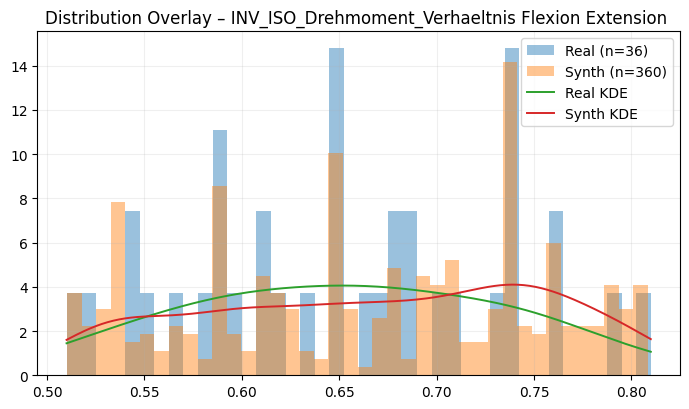

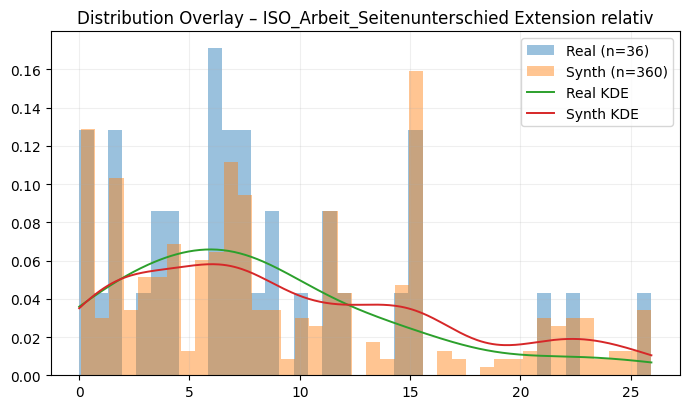

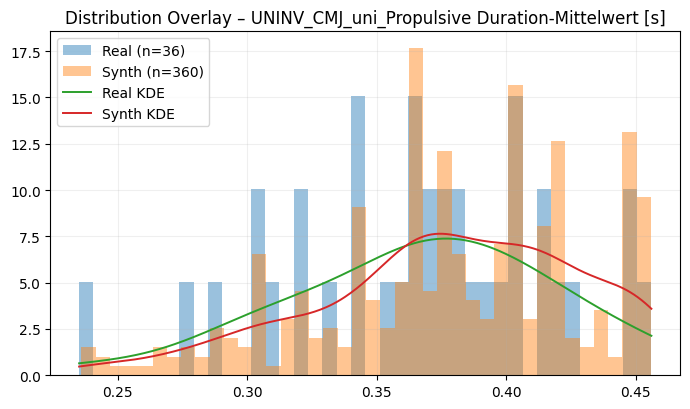

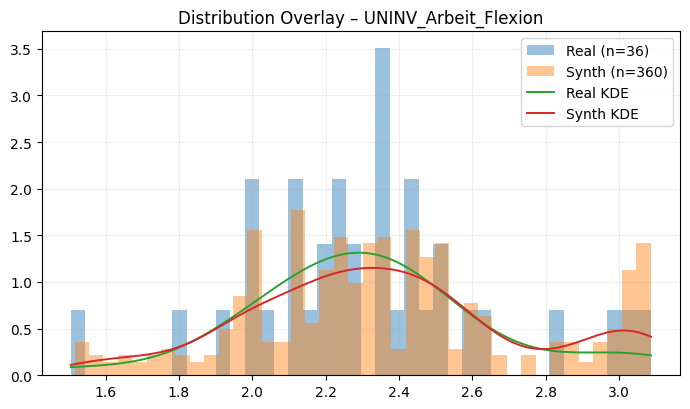

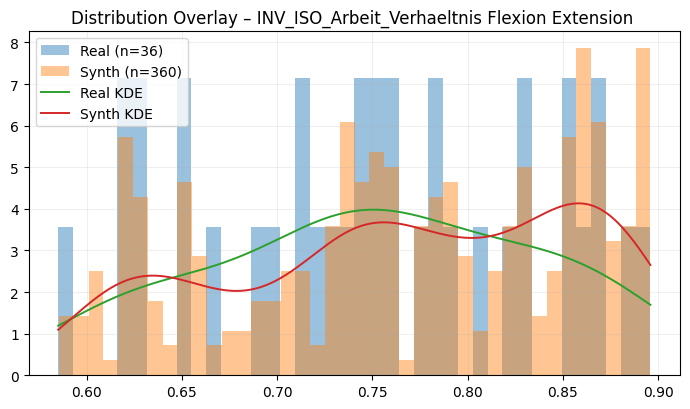

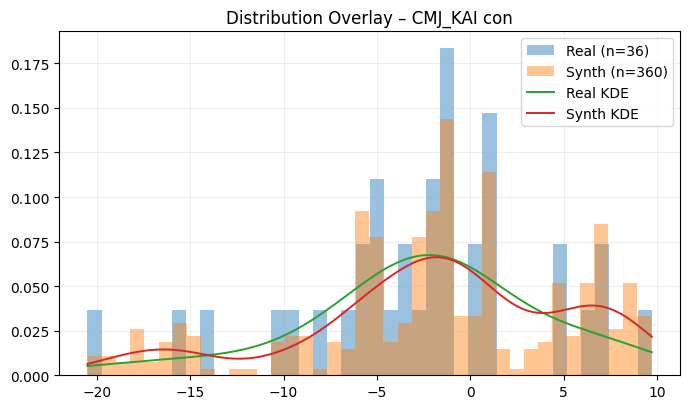

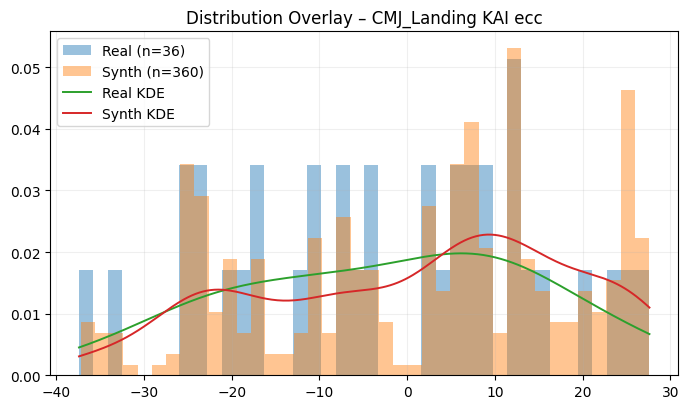

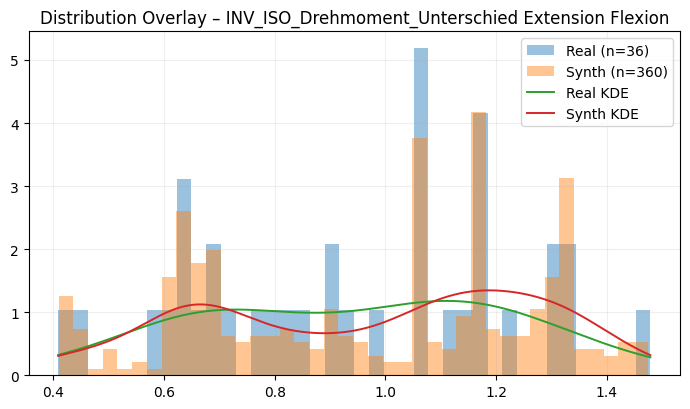

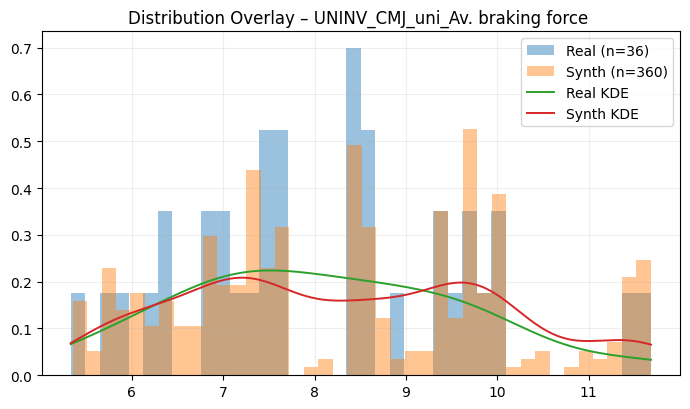

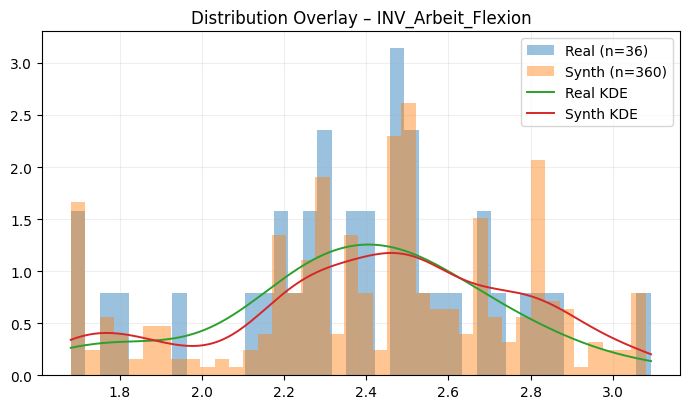

  Multivariat: EnergyDist=-0.4175 | MMD=0.0037 | ΔR_Fro=0.1912 | SignFlips=675 (10.9%)
  Origin AUC (real vs. synth): 0.458  | disc=0.542  (ideal: AUC≈0.5, disc≈0.5)

— Klasse 1 —
  n_real=32, n_synth=320
  Univariate: signif(KS, FDR≤0.05) = 0 / 112 Features
                                             feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median  q_fdr
                            CMJ_Countermovement Time 0.165625 0.369550 0.292382   1.199571 0.116432    0.244614  0.073290    1.0
       INV_ISO_Arbeit_Verhaeltnis Flexion Extension  0.153125 0.466438 0.298540   1.319857 0.077063    0.248369  0.082251    1.0
                          CMJ_Jump Height flighttime 0.140625 0.574602 0.188434   1.223939 0.092815    0.209162  1.327220    1.0
   INV_ISO_Drehmoment_Verhaeltnis Flexion Extension  0.140625 0.574602 0.265857   1.095634 0.065158    0.189662  0.081487    1.0
                           CMJ_Countermovement depth 0.134375 0.631316 0.238831   1.057812 0.076

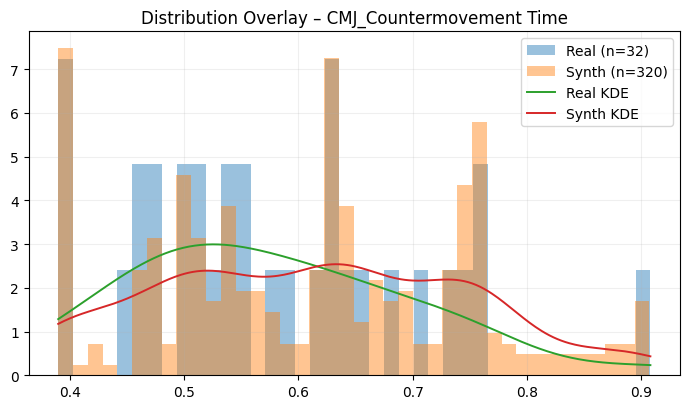

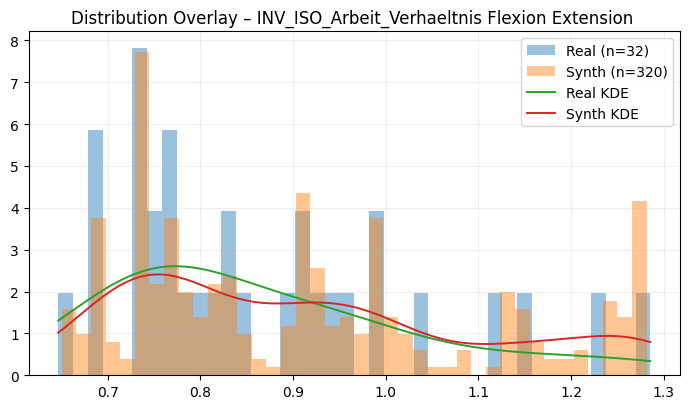

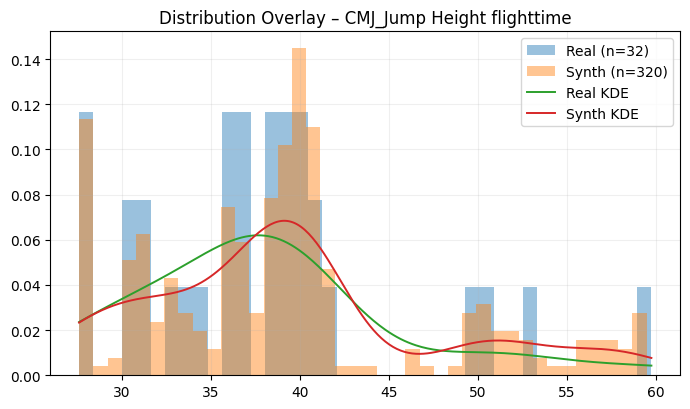

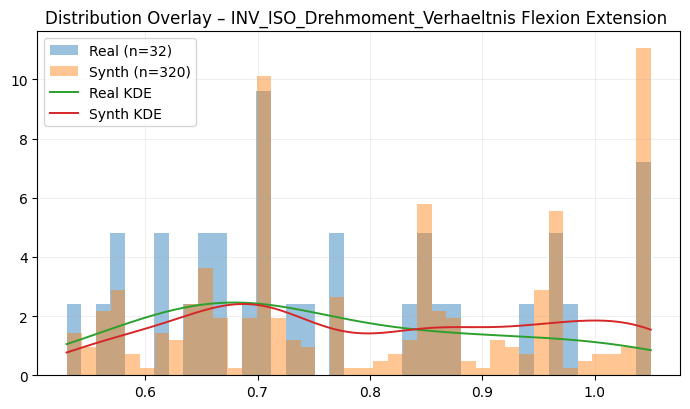

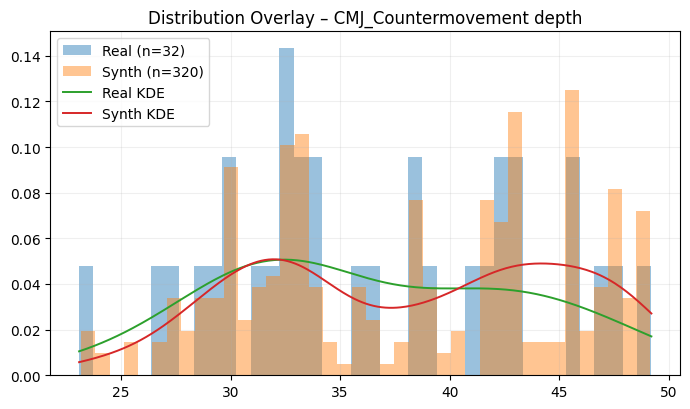

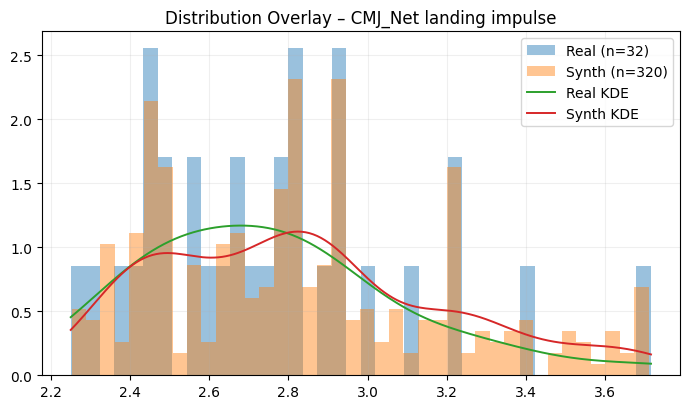

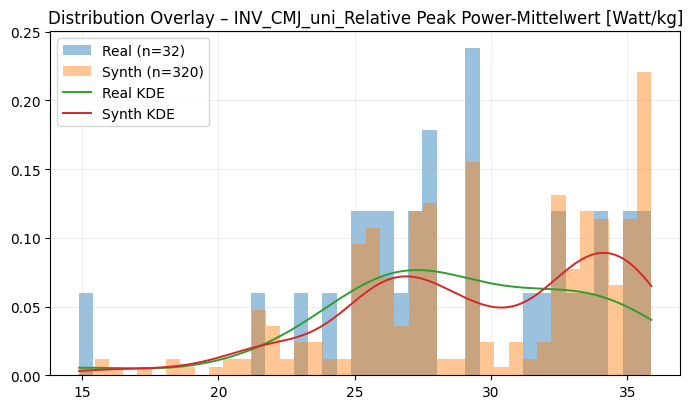

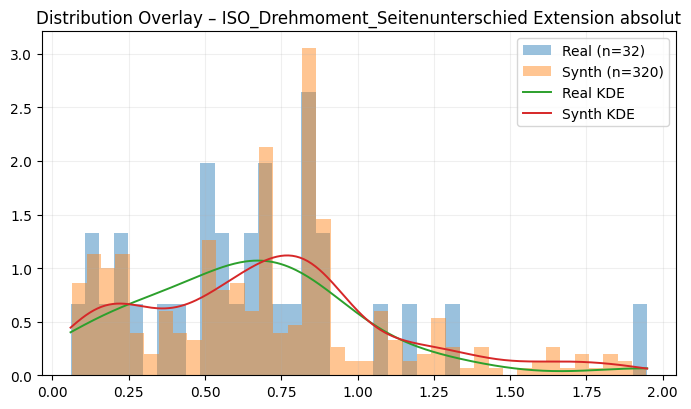

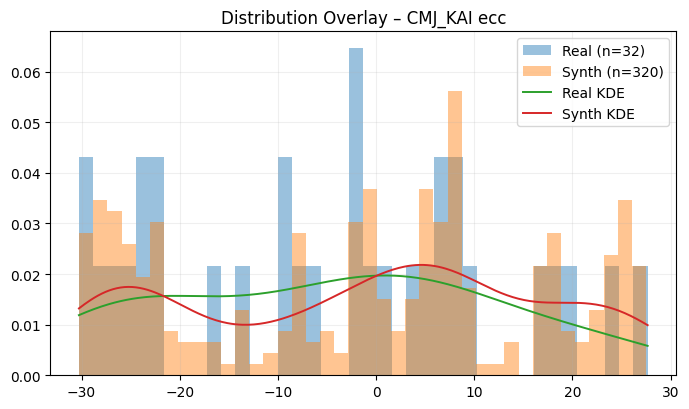

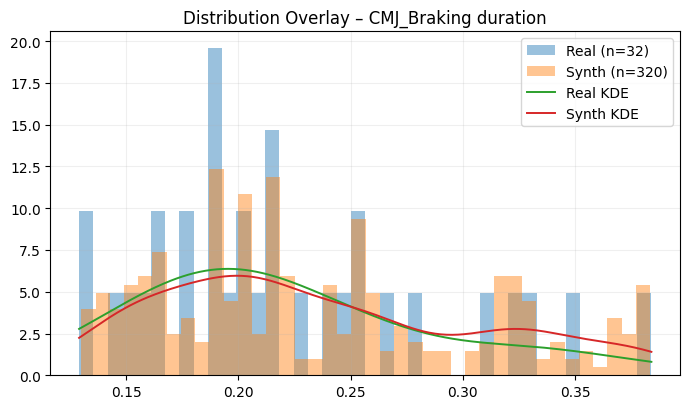

  Multivariat: EnergyDist=-0.5834 | MMD=0.0036 | ΔR_Fro=0.2084 | SignFlips=795 (12.8%)
  Origin AUC (real vs. synth): 0.395  | disc=0.605  (ideal: AUC≈0.5, disc≈0.5)

=== Zusammenfassung (konsole) ===
 cls  n_real  n_synth    energy      mmd   dR_fro  flips  flips_pct  origin_auc  origin_disc  ks_signif  n_feat
   0      36      360 -0.417545 0.003691 0.191178    675  10.859073    0.458163     0.541837          0     112
   1      32      320 -0.583436 0.003576 0.208351    795  12.789575    0.395238     0.604762          0     112

── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch).

In [36]:
run_qa_for_copula(
    data_path=r"K:\Team\Böhmer_Michael\PAPER\Neuronales_Netz\Motum_Datensatz\Basistabelle_ML_vkb_male.xlsx",
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=10,
    show_full_table=False
)


=== QA: Basistabelle_ML_vkb_male.xlsx ===
Original N=68, Synth N=634, Multiplier≈11

— Klasse 0 —
  n_real=36, n_synth=334
  Univariate: signif(KS, FDR≤0.05) = 0 / 112 Features
                                                                 feature       ks        p       smd  var_ratio      psi  w_over_iqr  d_median    q_fdr
                             INV_CMJ_uni_Braking Duration-Mittelwert [s] 0.250333 0.027697 -0.053129   0.725396 0.764333   23.854251  0.000155 0.999918
   UNINV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s] 0.250333 0.027697 -0.041216   0.758648 0.928418   16.642378  0.000468 0.999918
   UNINV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittelwert [m/s] 0.204923 0.112016  0.298200  17.615332 0.211193    1.731342  0.000536 0.999918
                      INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s] 0.195110 0.145968 -0.256473  11.771646 0.116800    1.163579  0.000170 0.999918
     INV_CMJ_uni_Durchschnittliche Schubgeschwindigkeit-Mittel

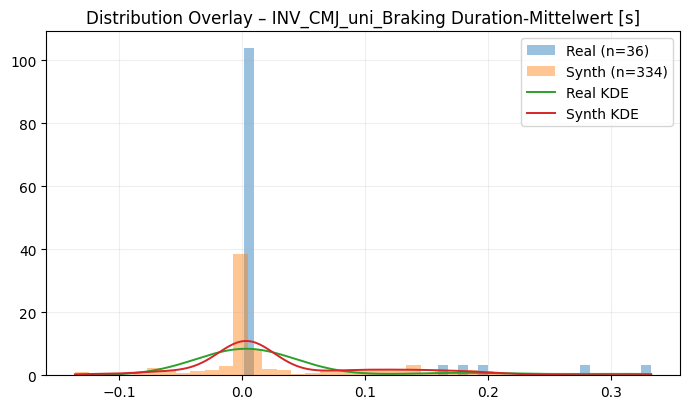

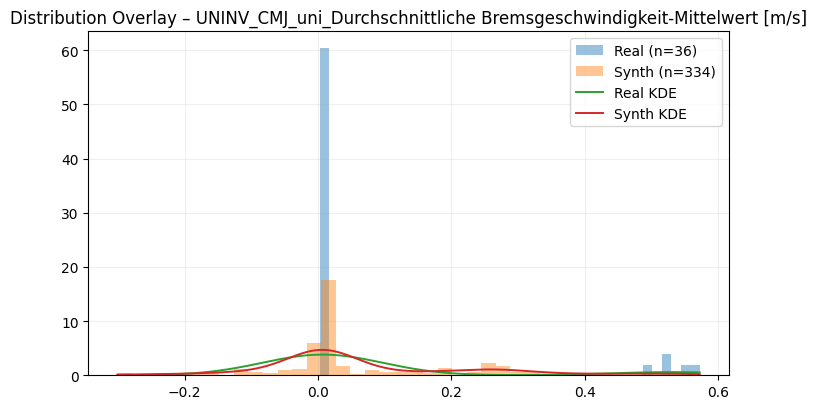

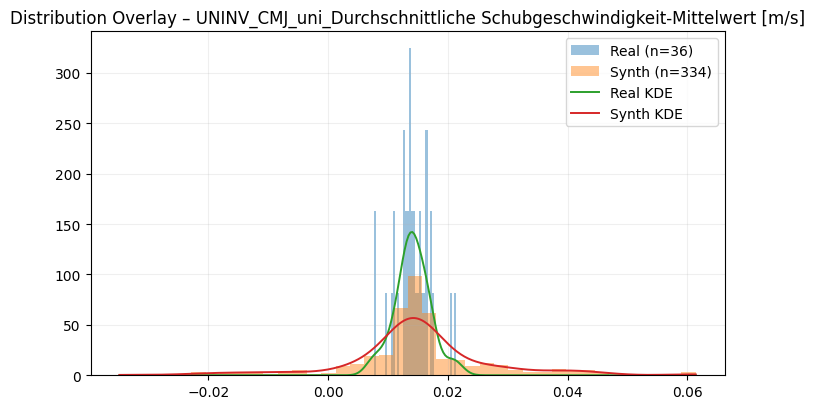

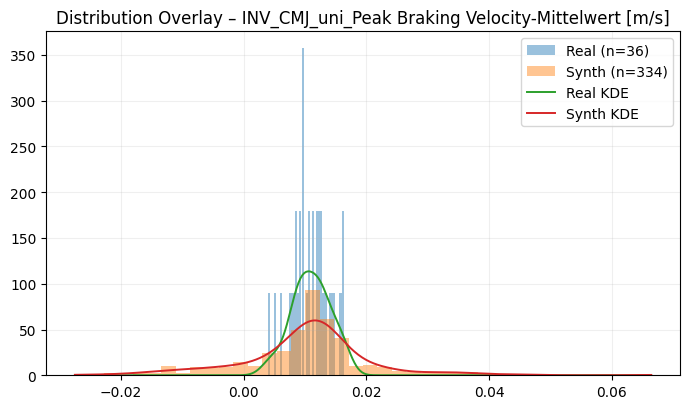

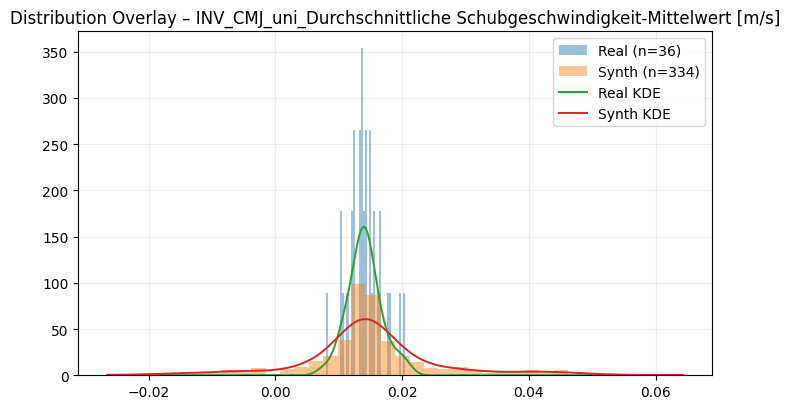

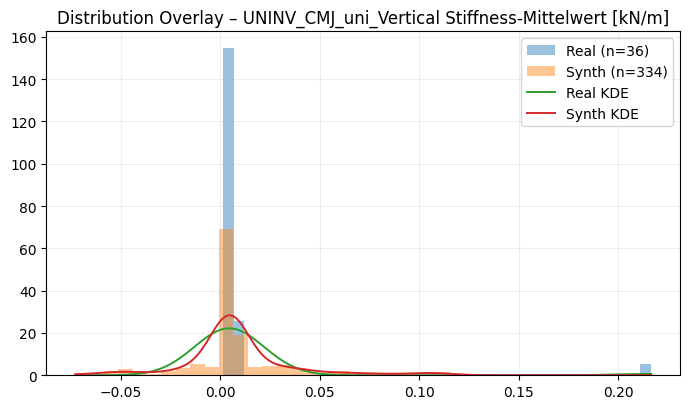

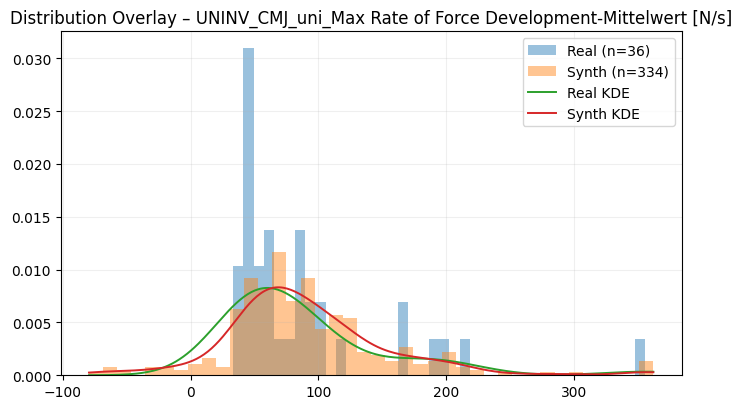

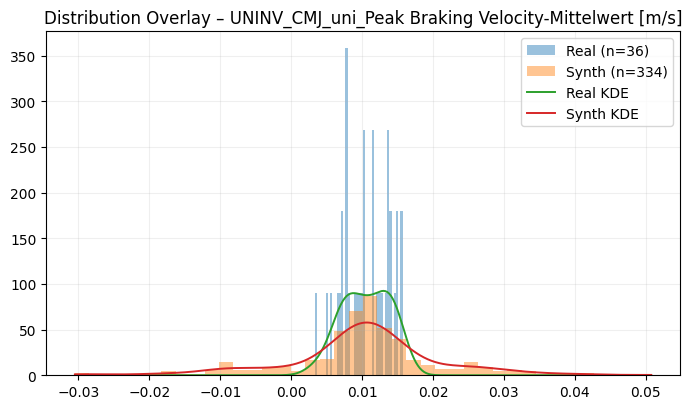

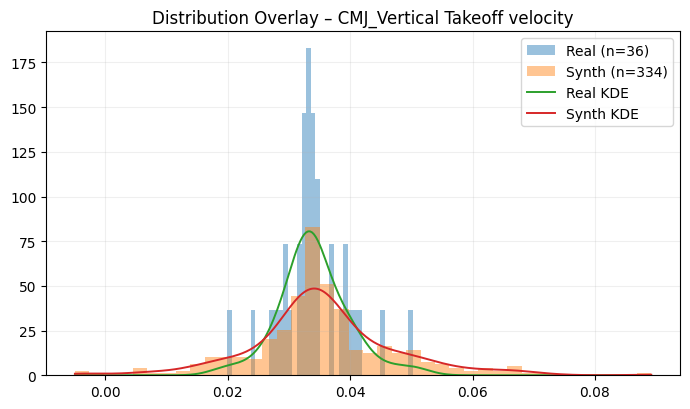

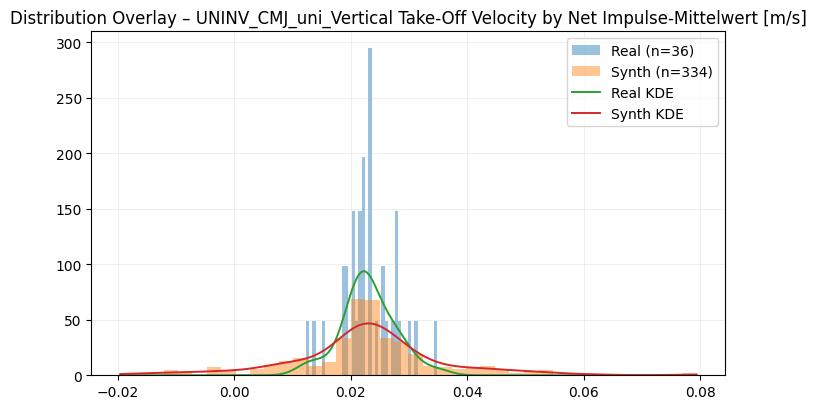

  Multivariat: EnergyDist=-2.3008 | MMD=-0.0067 | ΔR_Fro=0.2053 | SignFlips=1029 (16.6%)
  Origin AUC (real vs. synth): 0.149  | disc=0.851  (ideal: AUC≈0.5, disc≈0.5)

— Klasse 1 —
  n_real=32, n_synth=300
  Univariate: signif(KS, FDR≤0.05) = 0 / 112 Features
                                                              feature       ks        p       smd  var_ratio      psi  w_over_iqr  d_median    q_fdr
  INV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s] 0.247500 0.047707  0.106859   0.799199 0.968556    0.129230 -0.019154 0.998367
UNINV_CMJ_uni_Durchschnittliche Bremsgeschwindigkeit-Mittelwert [m/s] 0.235833 0.067017 -0.064177   0.863943 1.037872    0.167342  0.191920 0.998367
                        UNINV_CMJ_uni_Braking Duration-Mittelwert [s] 0.227500 0.084570  0.060420   0.830812 0.853053    0.131994 -0.020826 0.998367
                                          CMJ_Rel. Peak landing force 0.220833 0.101236  0.127818   0.930984 0.319652    0.187838  0.761440 0.9

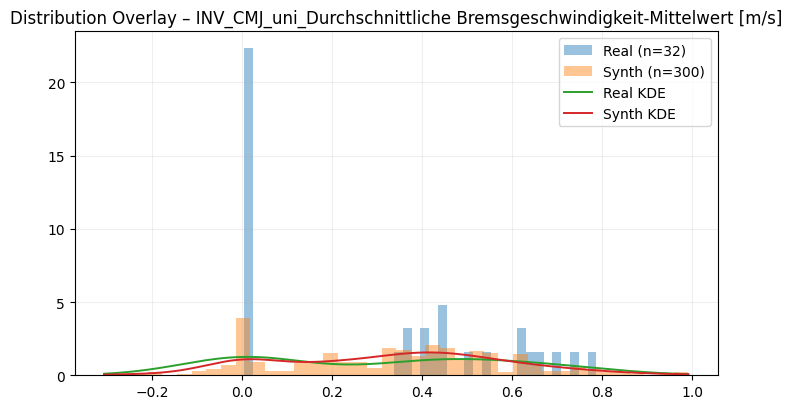

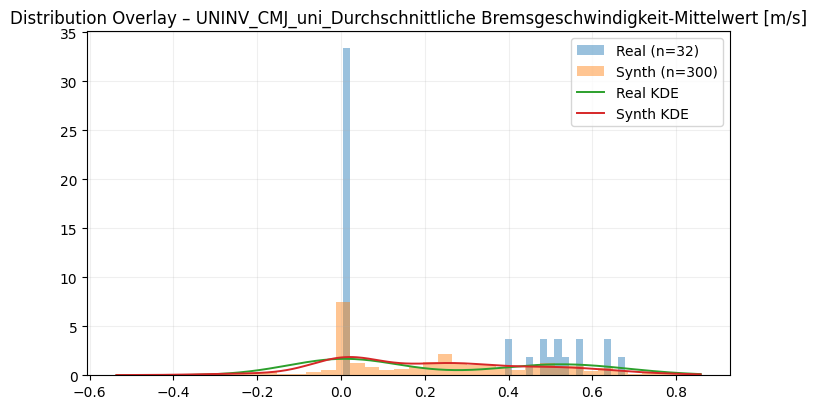

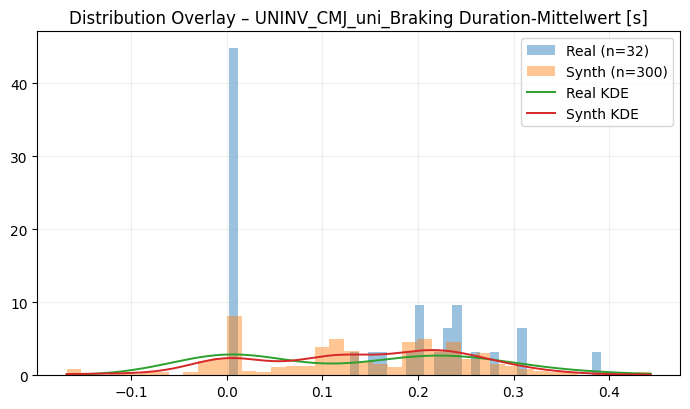

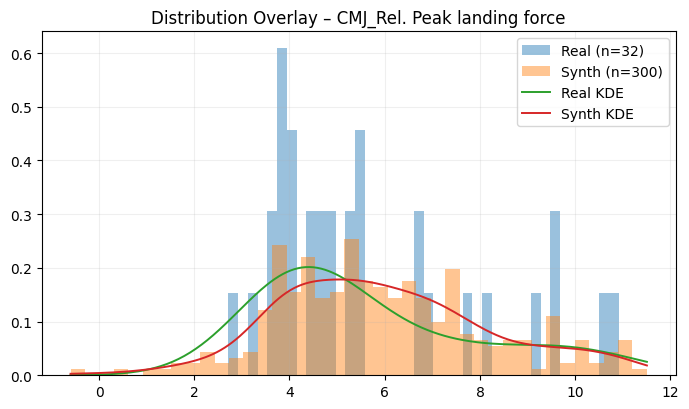

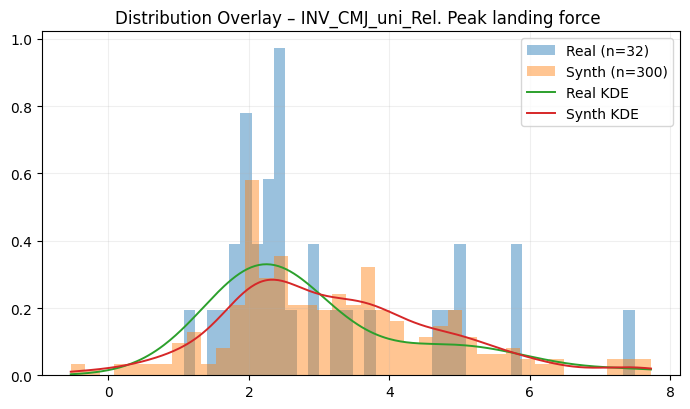

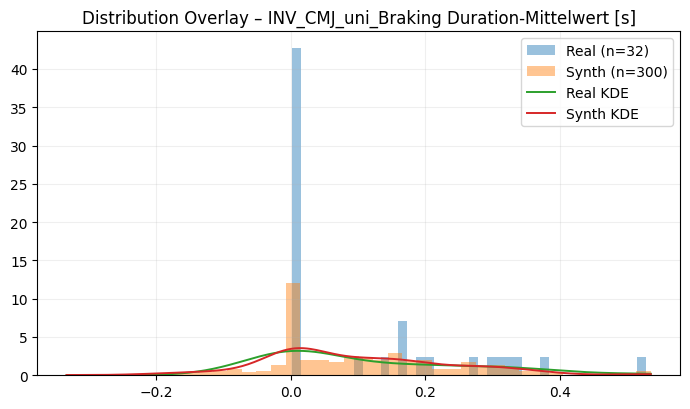

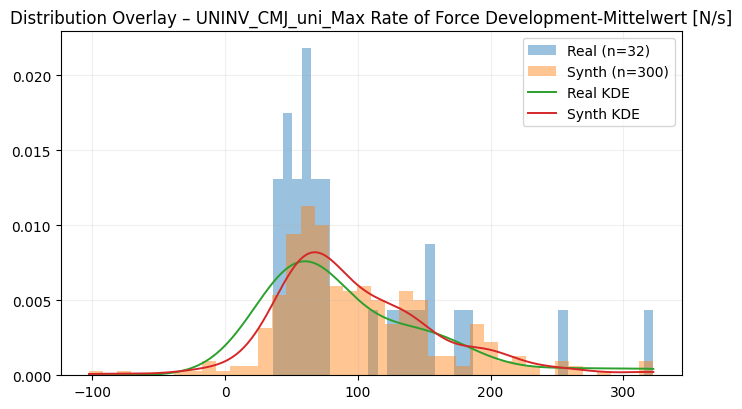

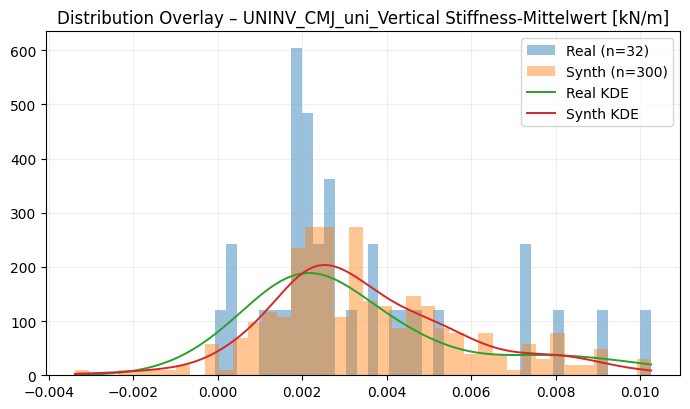

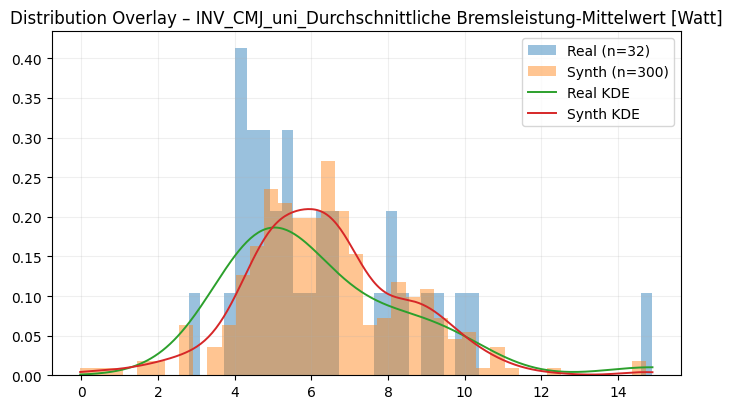

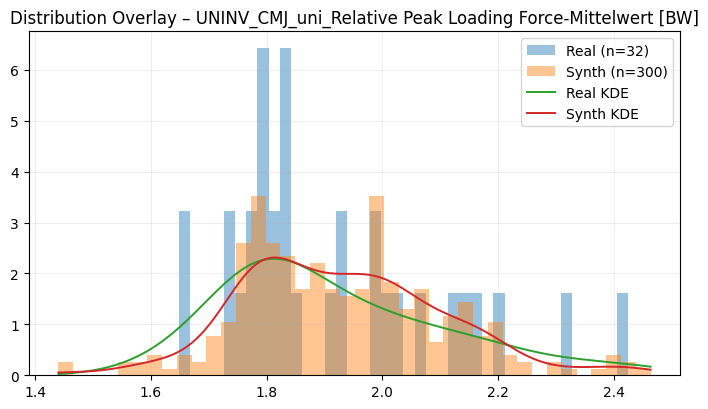

  Multivariat: EnergyDist=-2.0062 | MMD=-0.0001 | ΔR_Fro=0.1822 | SignFlips=981 (15.8%)
  Origin AUC (real vs. synth): 0.252  | disc=0.748  (ideal: AUC≈0.5, disc≈0.5)

=== Zusammenfassung (konsole) ===
 cls  n_real  n_synth    energy       mmd   dR_fro  flips  flips_pct  origin_auc  origin_disc  ks_signif  n_feat
   0      36      334 -2.300812 -0.006663 0.205334   1029  16.554054    0.149490     0.850510          0     112
   1      32      300 -2.006213 -0.000091 0.182188    981  15.781853    0.252381     0.747619          0     112

── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identis

In [21]:
run_qa_for_file_display(
    data_path=r"K:\Team\Böhmer_Michael\PAPER\Neuronales_Netz\Motum_Datensatz\Basistabelle_ML_vkb_male.xlsx",
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=10,
    show_full_table=False
)


### QA: MOTUM + Maestroni (reduziert)


=== QA: Datensatz_kombiniert_reduziert.xlsx ===
Original N=143, Synth N=1430, Multiplier≈11

— Klasse 0 —
  n_real=71, n_synth=710
  Univariate: signif(KS, FDR≤0.05) = 0 / 27 Features
                                                        feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median  q_fdr
  INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt] 0.064789 0.936414 0.116065   1.096434 0.028070    0.096799  0.037080    1.0
                                              LSI_ISO_Extension 0.064789 0.936414 0.078735   0.908065 0.013463    0.071156  0.870996    1.0
            UNINV_ISO_Drehmoment_Verhaeltnis Flexion Extension  0.063380 0.946181 0.108272   1.100581 0.015499    0.072734  0.009909    1.0
                                 INV_CMJ_uni_Av. braking force  0.061972 0.955000 0.011905   1.006232 0.024676    0.032341  0.000472    1.0
                 INV_CMJ_uni_Propulsive Duration-Mittelwert [s] 0.061972 0.955000 0.070382   1.012259 0.029437    0

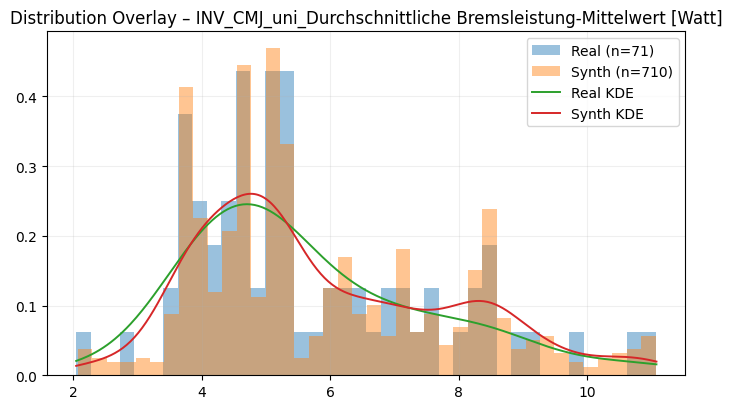

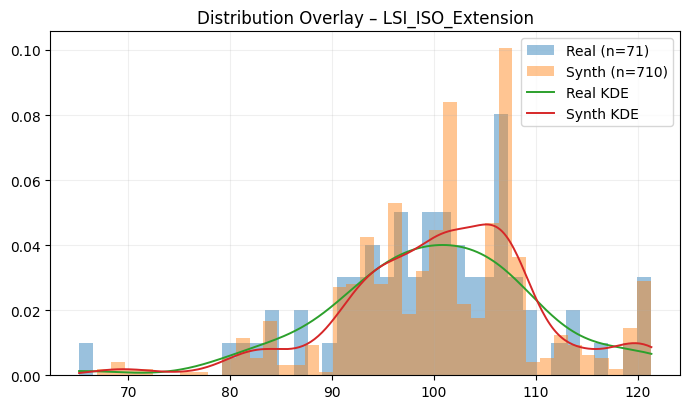

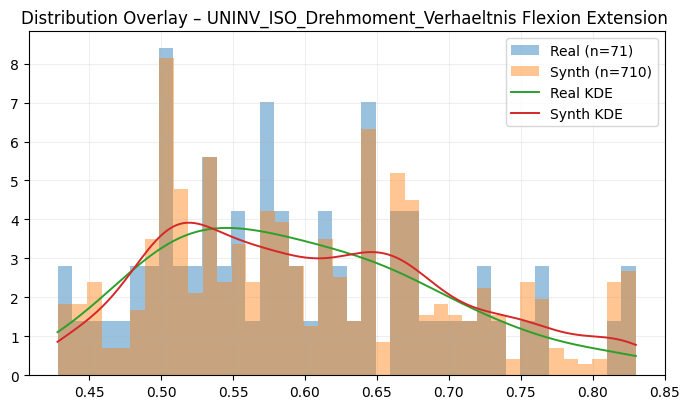

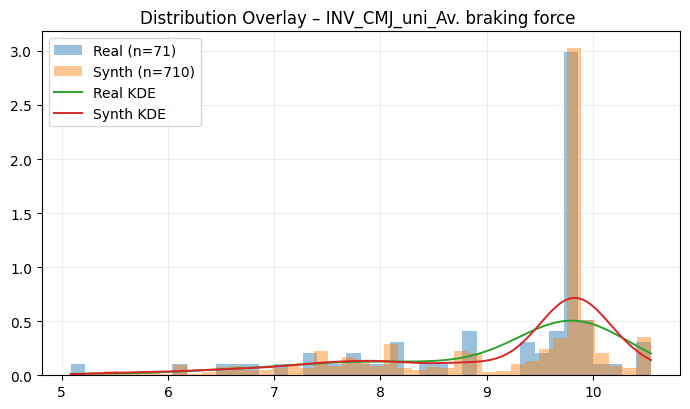

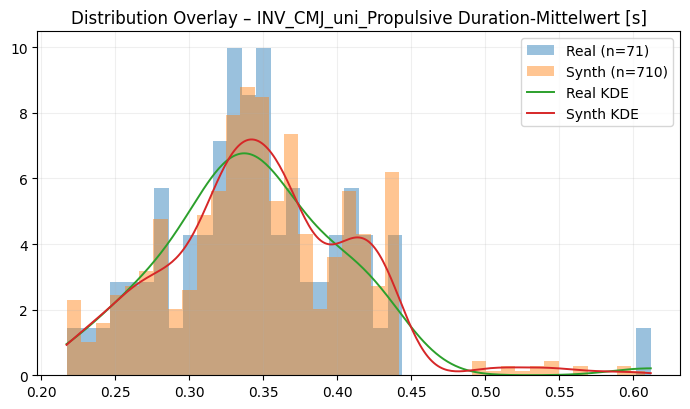

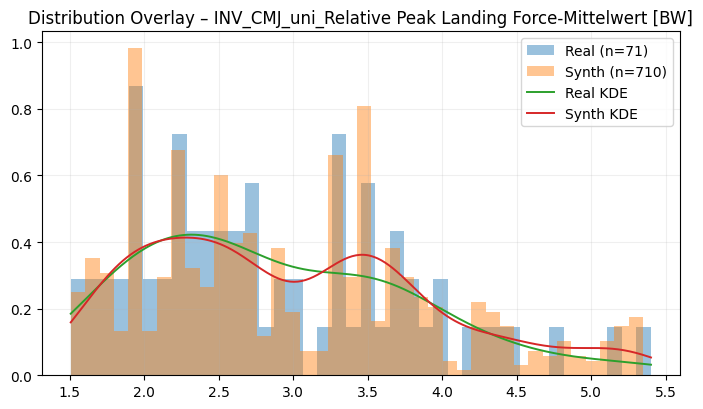

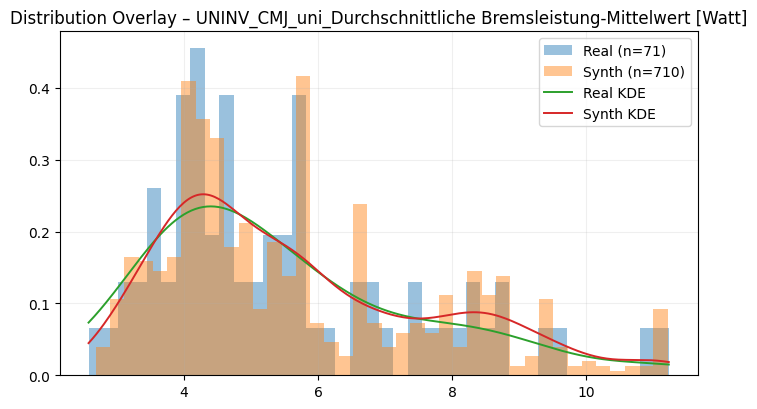

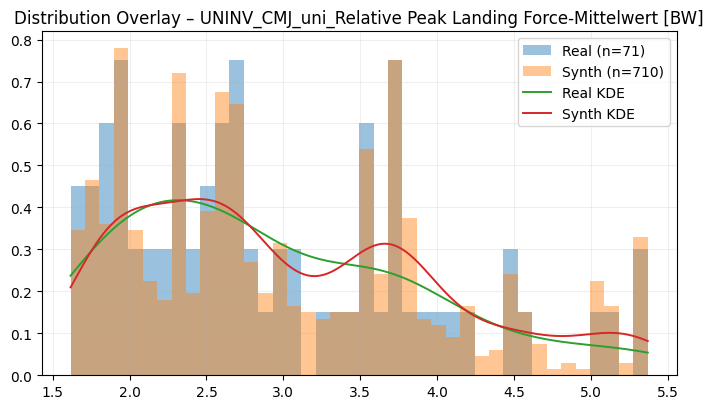

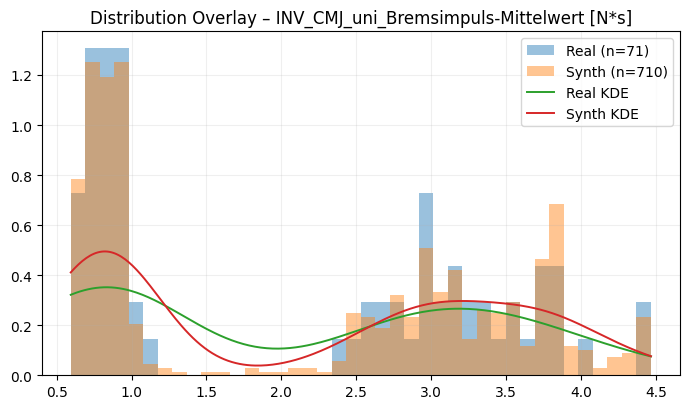

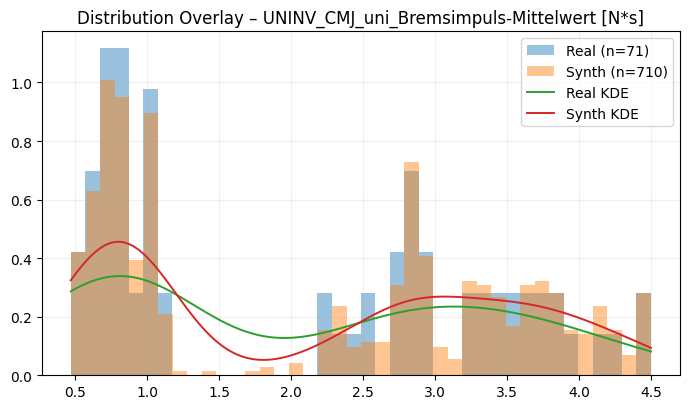

  Multivariat: EnergyDist=-0.1427 | MMD=-0.0047 | ΔR_Fro=0.2270 | SignFlips=17 (4.8%)
  Origin AUC (real vs. synth): 0.286  | disc=0.714  (ideal: AUC≈0.5, disc≈0.5)

— Klasse 1 —
  n_real=72, n_synth=720
  Univariate: signif(KS, FDR≤0.05) = 0 / 27 Features
                                                      feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median    q_fdr
               INV_CMJ_uni_Propulsive Duration-Mittelwert [s] 0.077778 0.800149 0.116720   1.023112 0.027833    0.122510  0.008945 0.999999
                   UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s] 0.062500 0.949123 0.094620   1.077974 0.028527    0.052700  0.171262 0.999999
             UNINV_CMJ_uni_Propulsive Duration-Mittelwert [s] 0.062500 0.949123 0.092842   1.034961 0.020519    0.068027  0.004265 0.999999
                                            LSI_ISO_Extension 0.062500 0.949123 0.064278   0.982012 0.022567    0.078748  1.249908 0.999999
INV_CMJ_uni_Durchschnittliche Bremsleistung

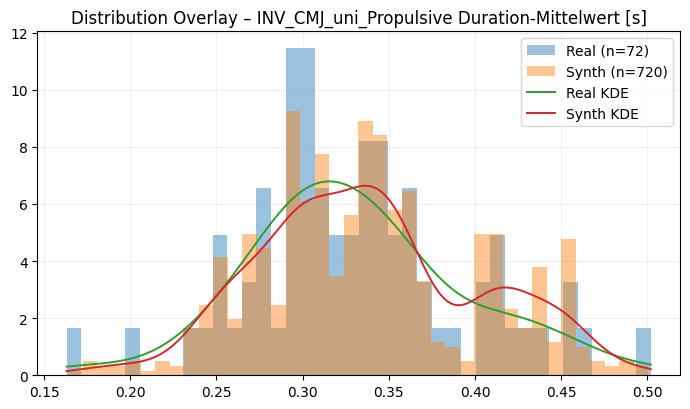

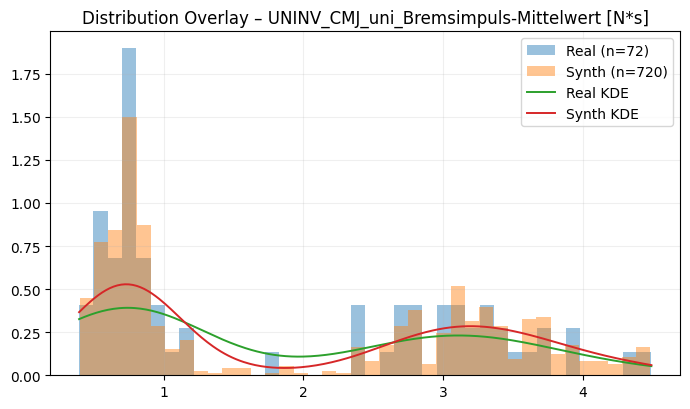

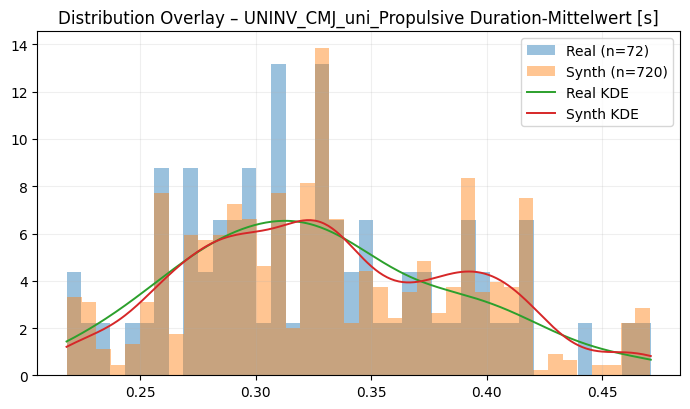

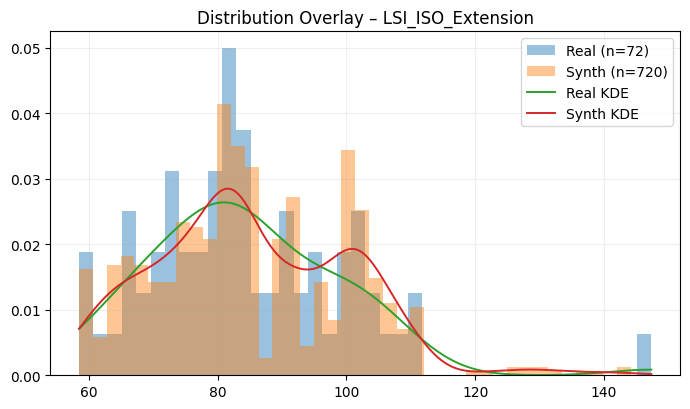

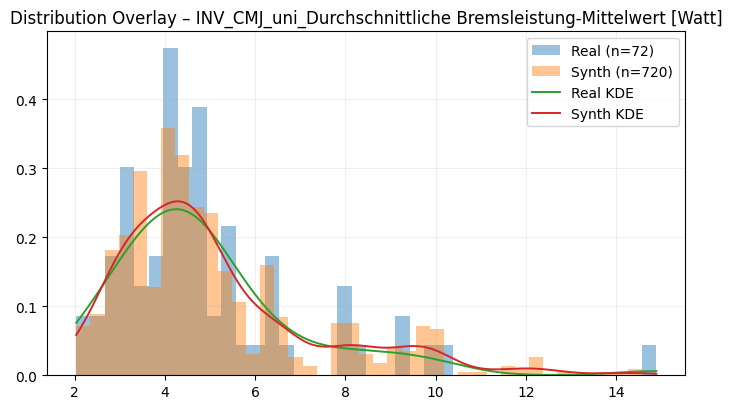

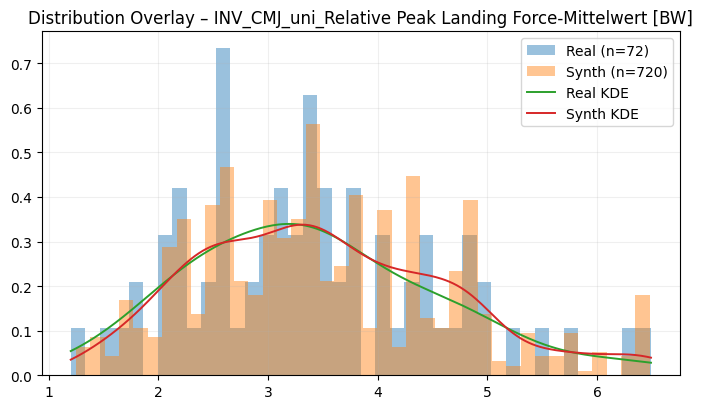

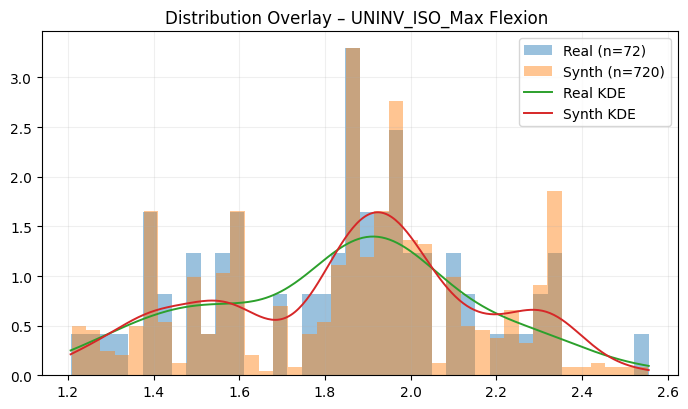

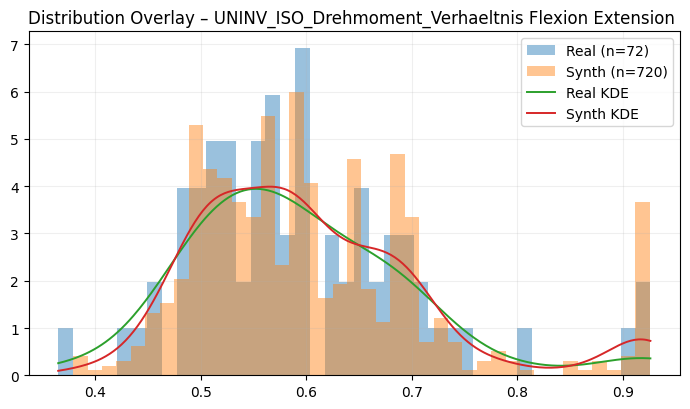

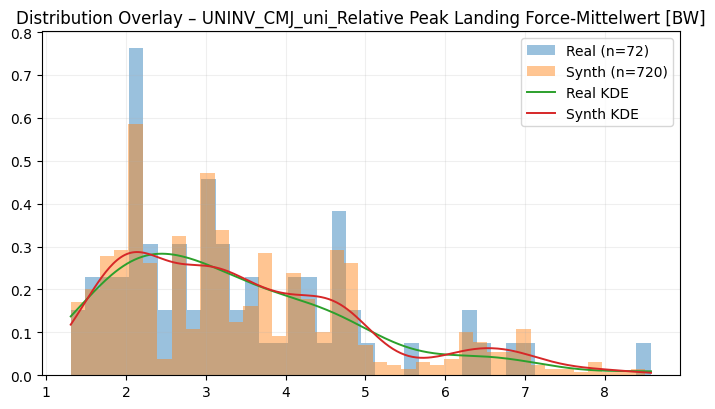

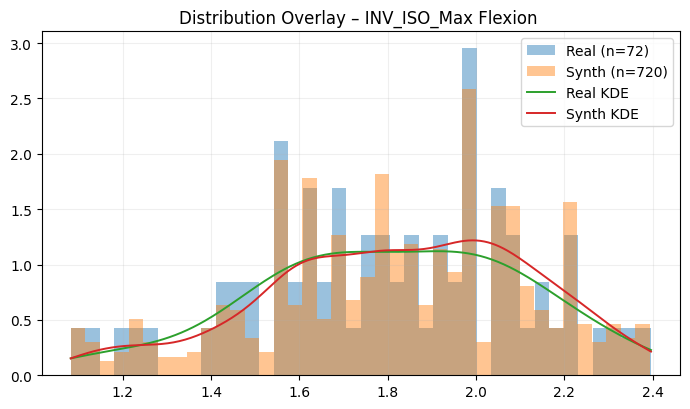

  Multivariat: EnergyDist=-0.1352 | MMD=-0.0028 | ΔR_Fro=0.2113 | SignFlips=14 (4.0%)
  Origin AUC (real vs. synth): 0.471  | disc=0.529  (ideal: AUC≈0.5, disc≈0.5)

=== Zusammenfassung (konsole) ===
 cls  n_real  n_synth    energy       mmd   dR_fro  flips  flips_pct  origin_auc  origin_disc  ks_signif  n_feat
   0      71      710 -0.142709 -0.004703 0.227004     17   4.843305    0.285918     0.714082          0      27
   1      72      720 -0.135248 -0.002806 0.211330     14   3.988604    0.471088     0.528912          0      27

── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch

In [38]:
run_qa_for_copula(
    data_path=r"K:\Team\Böhmer_Michael\PAPER\Neuronales_Netz\Motum_Maestroni_kombiniert\Datensatz_kombiniert_reduziert.xlsx",
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=10,
    show_full_table=False
)

### Copula QA: MOTUM (reduziert)


=== QA: Motum_ML.xlsx ===
Original N=68, Synth N=680, Multiplier≈11

— Klasse 0 —
  n_real=36, n_synth=360
  Univariate: signif(KS, FDR≤0.05) = 0 / 27 Features
                                                        feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median  q_fdr
               INV_CMJ_uni_Peak Propulsive Force-Mittelwert [N] 0.136111 0.543263 0.196146   1.181228 0.091383    0.157339  0.275599    1.0
             INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s] 0.125000 0.649671 0.121324   1.297639 0.127564    0.167598  0.000874    1.0
                                 INV_CMJ_uni_Av. braking force  0.122222 0.676601 0.090890   1.205683 0.090354    0.105510  0.274263    1.0
  INV_CMJ_uni_Durchschnittliche Bremsleistung-Mittelwert [Watt] 0.113889 0.755985 0.105900   1.191395 0.078713    0.112925  0.332046    1.0
                                INV_CMJ_uni_Peak braking force  0.111111 0.781438 0.119961   1.119235 0.101765    0.110476  0.631959    1.0

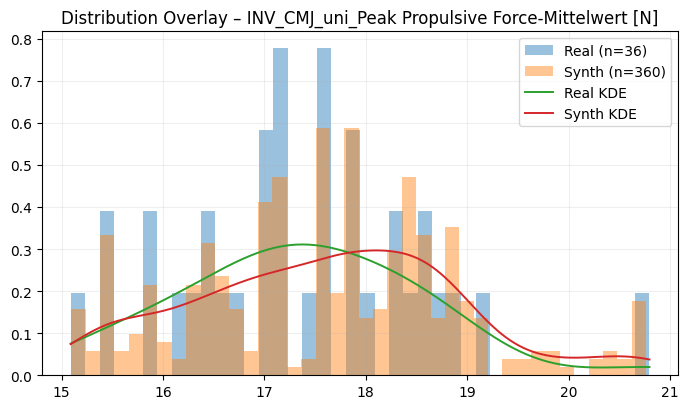

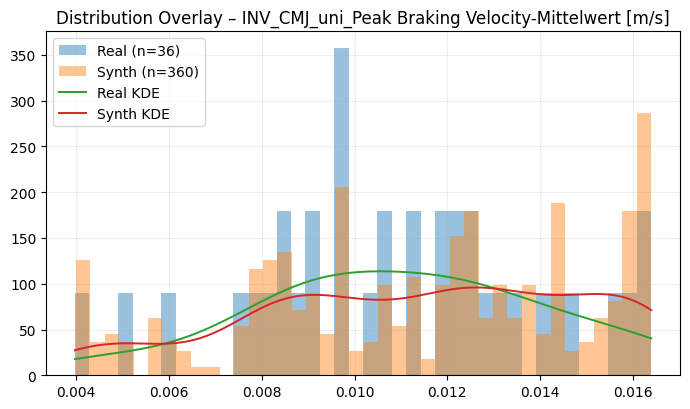

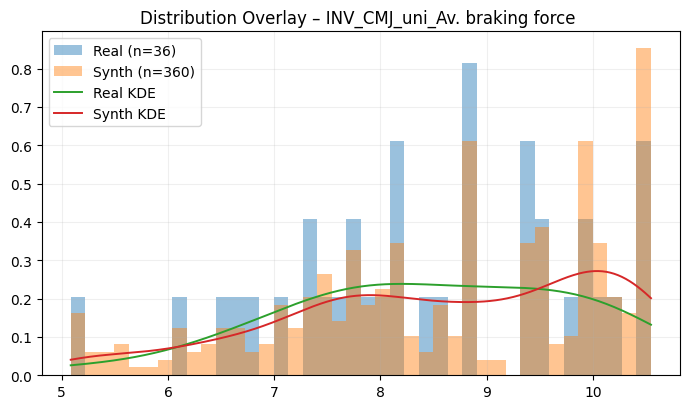

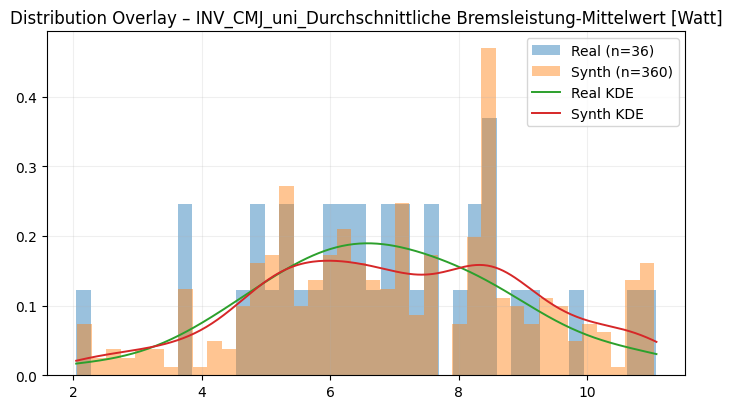

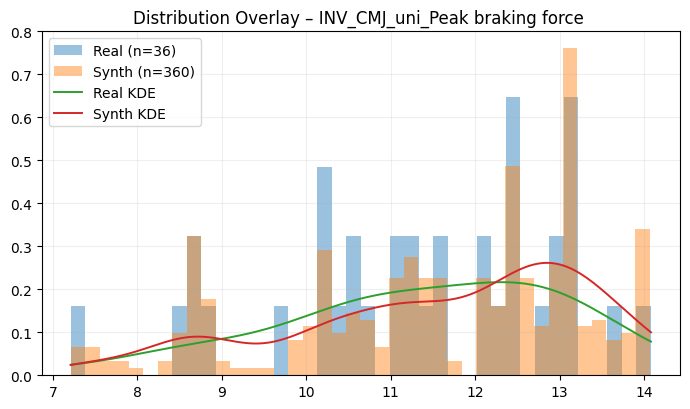

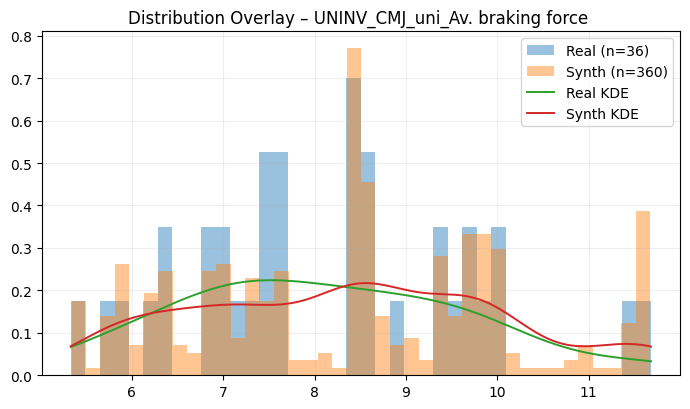

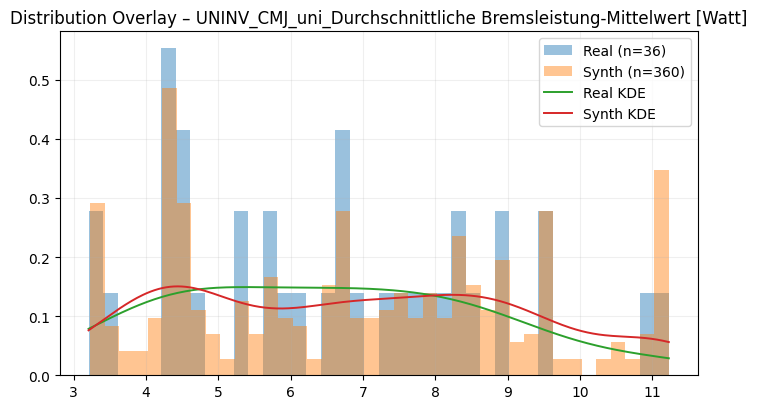

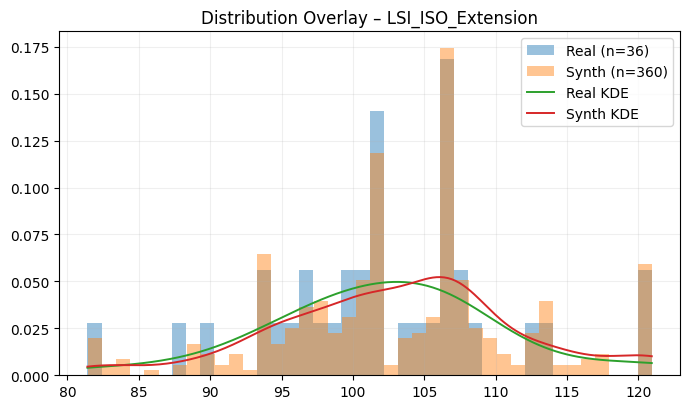

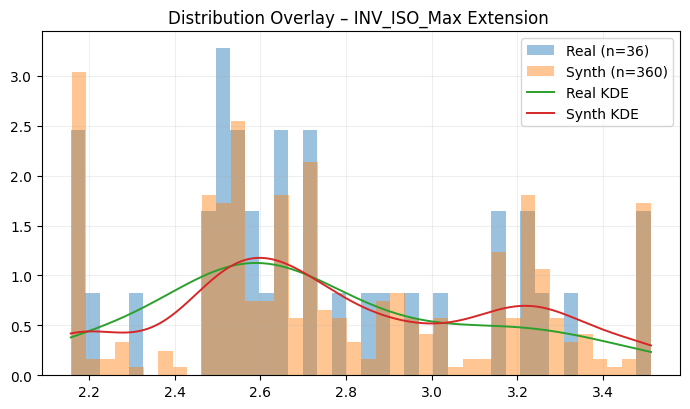

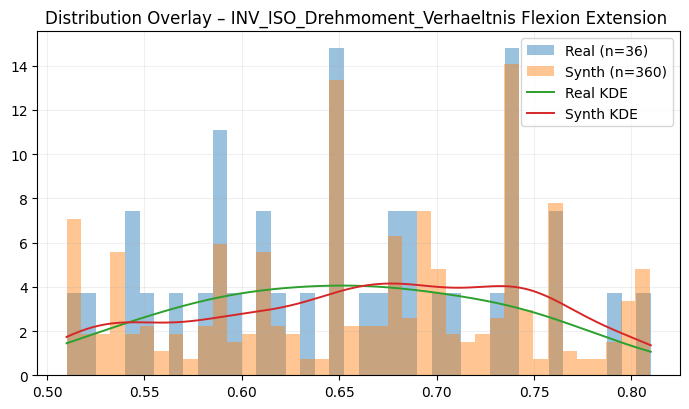

  Multivariat: EnergyDist=-0.1333 | MMD=-0.0069 | ΔR_Fro=0.2023 | SignFlips=23 (6.6%)
  Origin AUC (real vs. synth): 0.400  | disc=0.600  (ideal: AUC≈0.5, disc≈0.5)

— Klasse 1 —
  n_real=32, n_synth=320
  Univariate: signif(KS, FDR≤0.05) = 0 / 27 Features
                                                feature       ks        p      smd  var_ratio      psi  w_over_iqr  d_median  q_fdr
             UNINV_CMJ_uni_Bremsimpuls-Mittelwert [N*s] 0.125000 0.716744 0.153310   1.211103 0.073996    0.166718  0.053248    1.0
                      UNINV_CMJ_uni_Peak braking force  0.115625 0.798453 0.191703   1.198125 0.056000    0.155245  0.441136    1.0
                                 INV_ISO_Max Extension  0.112500 0.823931 0.107797   1.126268 0.058454    0.098237  0.138771    1.0
                                      LSI_ISO_Extension 0.112500 0.823931 0.125573   0.994935 0.037878    0.158626  1.124201    1.0
     INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s] 0.106250 0.870950 0.219760 

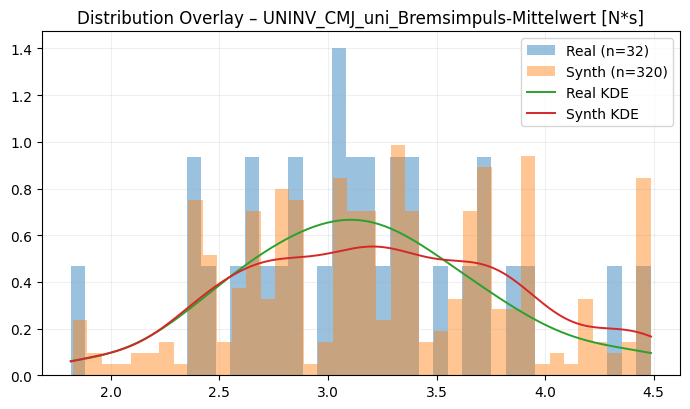

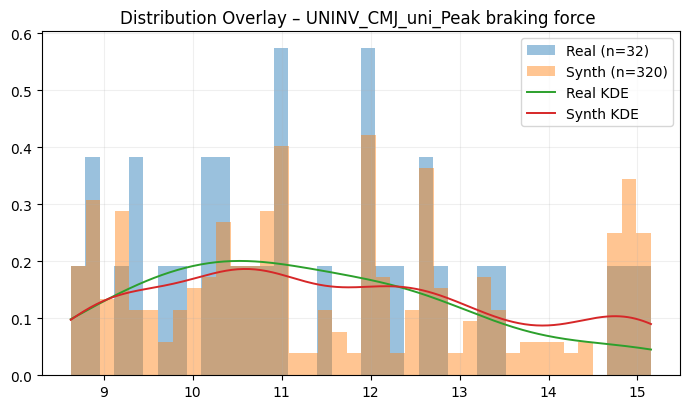

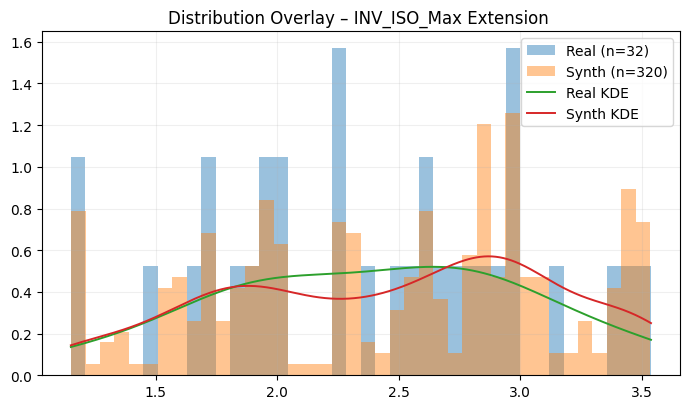

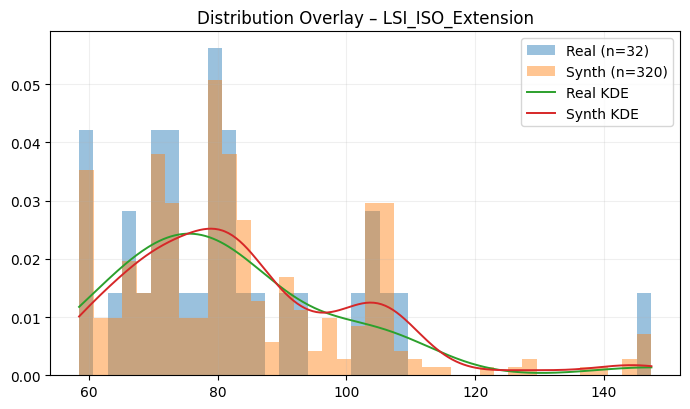

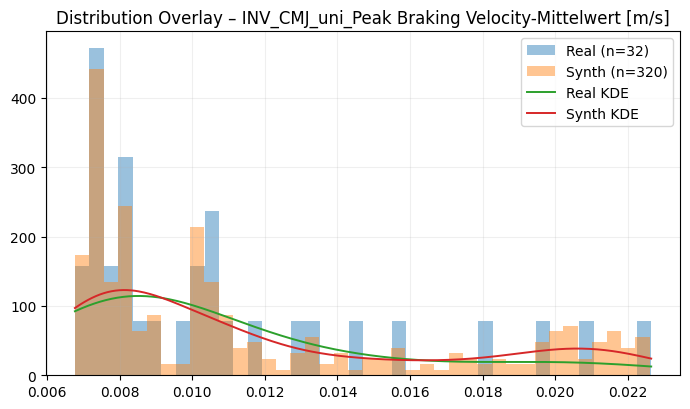

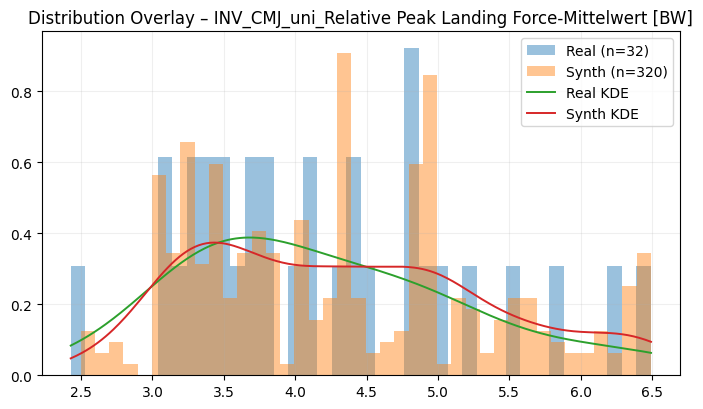

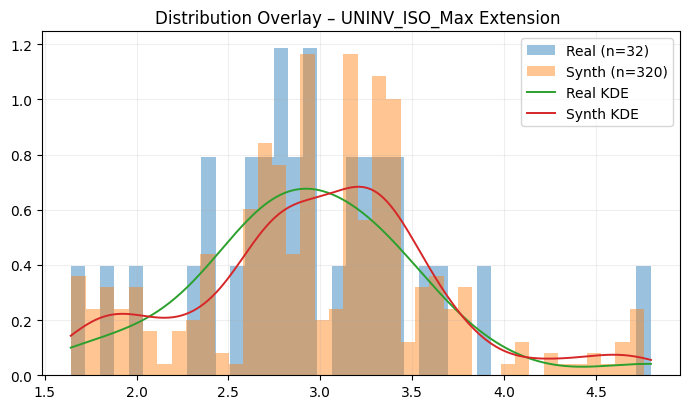

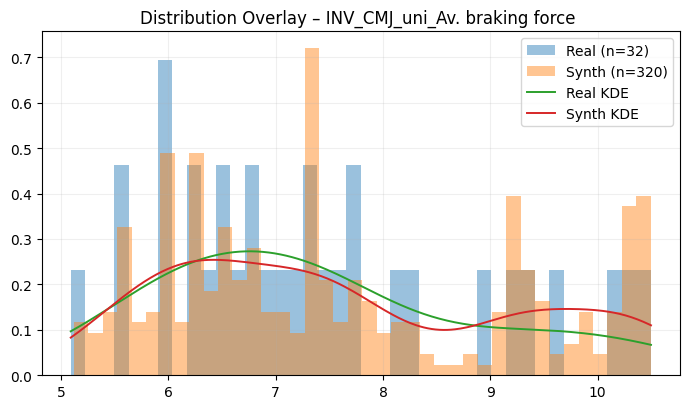

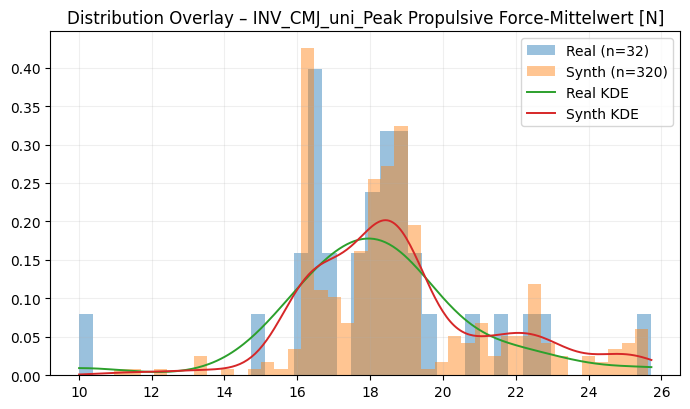

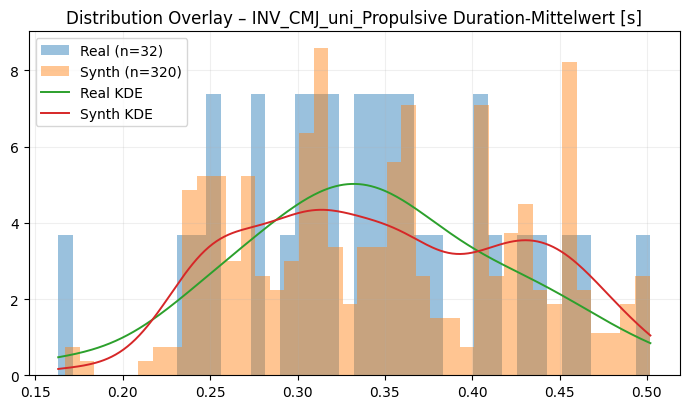

  Multivariat: EnergyDist=-0.3412 | MMD=-0.0074 | ΔR_Fro=0.2103 | SignFlips=30 (8.5%)
  Origin AUC (real vs. synth): 0.432  | disc=0.568  (ideal: AUC≈0.5, disc≈0.5)

=== Zusammenfassung (konsole) ===
 cls  n_real  n_synth    energy       mmd   dR_fro  flips  flips_pct  origin_auc  origin_disc  ks_signif  n_feat
   0      36      360 -0.133266 -0.006890 0.202325     23   6.552707    0.400000     0.600000          0      27
   1      32      320 -0.341183 -0.007434 0.210284     30   8.547009    0.431746     0.568254          0      27

── Kurzlegende QA-Metriken ─────────────────────────────────────────────
• KS (FDR): Kolmogorov–Smirnov-Test je Feature; nach FDR-korrigiert.
  Ziel: wenige/keine signifikanten Features (q ≥ 0.05).
• SMD / Var-Ratio / PSI / Wasserstein/IQR: Effektgrößen univariater Drift.
  Heuristik: SMD ≤ 0.2, Var-Ratio ∈ [0.5, 2], PSI ≤ 0.1 (0.1–0.25 beobachten),
  Wasserstein/IQR ≤ 0.2.
• Energy Distance / MMD: globale Verteilungsähnlichkeit (klein ≈ gut; 0 ≈ identisch

In [37]:
run_qa_for_copula(
    data_path=r"K:\Team\Böhmer_Michael\PAPER\Neuronales_Netz\Motum_Maestroni_kombiniert\Motum_ML.xlsx",
    target_column="Verletzungsstatus",
    target_augmentation_multiplier=11,
    plots_top_n=10,
    show_full_table=False
)